### ➡️ BERT ⬅️ 양방향 문맥을 고려하는 인코더 모델 만들기 (변신 모델에 기반) 

##### 준비 단계 - 파일 불러오기, 환경 설정하기

In [57]:
from __future__ import absolute_import, division, print_function, unicode_literals

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import os
import re
import math
import numpy as np
import pandas as pd
import random
import collections
import json
import shutil
import copy

import matplotlib.pyplot as plt
import sentencepiece as spm

random_seed = 1234
random.seed(random_seed)
np.random.seed(random_seed)

print(torch.__version__)

device = torch.device("mps" if torch.backends.mps.is_available() # mps->cuda->cpu
                       else "cuda" if torch.cuda.is_available()
                       else "cpu")
print("device:", device)

DATA_DIR = "."
MODEL_DIR = "./models"

os.makedirs(MODEL_DIR, exist_ok=True)

corpus_file = f'{DATA_DIR}/kowiki.txt'
assert os.path.exists(corpus_file), f"'{corpus_file}' 파일을 찾을 수 없습니다."

print("코퍼스 파일:", corpus_file)
print("파일 크기: {:.1f} MB".format(os.path.getsize(corpus_file) / (1024**2)))

with open(corpus_file, 'r', encoding='utf-8') as f:
    total_lines = sum(1 for _ in f)
print("전체 라인 수:", total_lines)

2.13.0
device: mps
코퍼스 파일: ./kowiki.txt
파일 크기: 635.7 MB
전체 라인 수: 3957761


---

##### 1. 토크나이저 만들기(SentencePiece 학습)

In [58]:
corpus_file = f'{DATA_DIR}/kowiki.txt'
prefix = f'{MODEL_DIR}/ko_8000'
vocab_size = 8000

# vocab_size + 7 의 7 = 예약 토큰 4개([PAD],[UNK],[BOS],[EOS]) + 사용자 정의 토큰 3개([SEP],[CLS],[MASK])
if not os.path.exists(f'{prefix}.model'):   # 이미 만들어져 있으면 재학습하지 않음
    spm.SentencePieceTrainer.train(
        f"--input={corpus_file} --model_prefix={prefix} --vocab_size={vocab_size + 7}"
        " --model_type=bpe --max_sentence_length=999999"
        " --input_sentence_size=1000000 --shuffle_input_sentence=true"
        " --pad_id=0 --pad_piece=[PAD] --unk_id=1 --unk_piece=[UNK]"
        " --bos_id=2 --bos_piece=[BOS] --eos_id=3 --eos_piece=[EOS]"
        " --user_defined_symbols=[SEP],[CLS],[MASK]"
    )
else:
    print(f"'{prefix}.model'이 이미 존재하여 재학습을 건너뜁니다.")

print(os.listdir(MODEL_DIR))

'./models/ko_8000.model'이 이미 존재하여 재학습을 건너뜁니다.
['ko_8000.vocab', 'ko_8000.model']


In [59]:
# 토크나이저 로드 및 확인
vocab = spm.SentencePieceProcessor()
vocab.load(f'{prefix}.model')

print("전체 vocab 크기:", len(vocab))   # 8000 + 7 = 8007 이어야 정상
print("PAD:", vocab.pad_id(), "/ UNK:", vocab.unk_id(),
      "/ BOS:", vocab.bos_id(), "/ EOS:", vocab.eos_id())
print("[SEP] id:", vocab.piece_to_id("[SEP]"))
print("[CLS] id:", vocab.piece_to_id("[CLS]"))
print("[MASK] id:", vocab.piece_to_id("[MASK]"))

전체 vocab 크기: 8007
PAD: 0 / UNK: 1 / BOS: 2 / EOS: 3
[SEP] id: 4
[CLS] id: 5
[MASK] id: 6


In [60]:
# 특수 토큰 7개를 제외한 나머지 vocab 확인
vocab_list = []
for id in range(7, len(vocab)):
    if not vocab.is_unknown(id):
        vocab_list.append(vocab.id_to_piece(id))

print("일반 토큰 개수:", len(vocab_list))
print("샘플:", vocab_list[:20])

일반 토큰 개수: 8000
샘플: ['▁1', '▁이', '으로', '에서', '▁있', '▁2', '▁그', '▁대', '▁사', '이다', '었다', '▁지', '▁수', '▁19', '▁가', '▁시', '▁20', '▁기', '▁전', '▁아']


In [61]:
# 실제 문장으로 토큰화 테스트
sample_text = "인공지능은 컴퓨터가 인간처럼 학습하고 판단하는 기술이다."
print("원문:", sample_text)
print("BPE 조각:", vocab.encode_as_pieces(sample_text))
print("토큰 ID:", vocab.encode_as_ids(sample_text))

원문: 인공지능은 컴퓨터가 인간처럼 학습하고 판단하는 기술이다.
BPE 조각: ['▁인', '공', '지', '능', '은', '▁컴퓨터', '가', '▁인간', '처럼', '▁학', '습', '하고', '▁판단', '하는', '▁기술', '이다', '.']
토큰 ID: [41, 3679, 3618, 3921, 3621, 1563, 3616, 1400, 857, 305, 4013, 47, 2984, 38, 785, 16, 3607]


---

##### 2. 전처리 - Mask 생성

In [62]:
# 테스트용 샘플 문장으로 흐름 확인
sample_text = "인공지능은 컴퓨터가 인간처럼 학습하고 판단하는 기술이다"
tokens_org = ["[CLS]"] + vocab.encode_as_pieces(sample_text) + ["[SEP]"]
print("tokens_org:", tokens_org)

# 전체 token의 15%를 mask 대상으로 함 ([CLS], [SEP] 2개는 제외)
mask_cnt = max(1, int((len(tokens_org) - 2) * 0.15))
print("mask 개수:", mask_cnt)

tokens_org: ['[CLS]', '▁인', '공', '지', '능', '은', '▁컴퓨터', '가', '▁인간', '처럼', '▁학', '습', '하고', '▁판단', '하는', '▁기술', '이다', '[SEP]']
mask 개수: 2


In [63]:
# 띄어쓰기(단어) 단위로 mask하기 위한 index 분할
# u"\u2581"는 SentencePiece가 "이 조각이 단어의 시작"임을 표시하는 특수 문자
cand_idx = []
for (i, token) in enumerate(tokens_org):
    if token == "[CLS]" or token == "[SEP]":
        continue
    if 0 < len(cand_idx) and not token.startswith(u"\u2581"):
        cand_idx[-1].append(i)   # 이전 단어에 이어붙는 조각이면 같은 그룹에 추가
    else:
        cand_idx.append([i])     # 새 단어 시작이면 새 그룹 생성

for cand in cand_idx:
    print(cand, [tokens_org[i] for i in cand])

[1, 2, 3, 4, 5] ['▁인', '공', '지', '능', '은']
[6, 7] ['▁컴퓨터', '가']
[8, 9] ['▁인간', '처럼']
[10, 11, 12] ['▁학', '습', '하고']
[13, 14] ['▁판단', '하는']
[15, 16] ['▁기술', '이다']


In [64]:
# create_pretrain_mask: MLM용 마스킹 함수
def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    """
    마스크 생성 (BERT MLM 규칙: 전체의 15%를 대상으로, 그 중 80%[MASK]/10%랜덤/10%원본유지)
    :param tokens: [CLS]...[SEP] 형태의 토큰 리스트 (이 함수 안에서 직접 값이 바뀜에 주의)
    :param mask_cnt: mask 개수 (전체 tokens의 15%)
    :param vocab_list: 랜덤 토큰 선택용 vocab 리스트 (1단계에서 만든 그 vocab_list)
    :return tokens: mask 적용된 tokens
    :return mask_idx: mask된 위치들 (오름차순 정렬)
    :return mask_label: 그 위치의 원래(정답) 토큰들
    """
    # 단어 단위로 mask 하기 위해서 index 분할 (띄어쓰기 기준)
    cand_idx = []
    for (i, token) in enumerate(tokens):
        if token == "[CLS]" or token == "[SEP]":
            continue
        if 0 < len(cand_idx) and not token.startswith(u"\u2581"):
            cand_idx[-1].append(i)
        else:
            cand_idx.append([i])

    # random mask를 위해서 그룹 순서를 섞음
    random.shuffle(cand_idx)

    mask_lms = []
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:          # 이미 15%를 채웠으면 중지
            break
        if len(mask_lms) + len(index_set) > mask_cnt:  # 이번 그룹까지 넣으면 15% 초과면 skip
            continue

        dice = random.random()   # 0~1 사이 확률 값 (그룹 전체가 같은 규칙을 따름)
        for index in index_set:
            if dice < 0.8:                          # 80% MASK로 
                masked_token = "[MASK]"
            elif dice < 0.9:                         # 10% 원래 토큰 그대로 유지
                masked_token = tokens[index]
            else:                                    # 10% 랜덤한 다른 토큰으로
                masked_token = random.choice(vocab_list)

            mask_lms.append({"index": index, "label": tokens[index]})  # 정답은 미리 저장해둠
            tokens[index] = masked_token   # 다음에 실제로 값을 바꿈

    # index 순서대로 정렬해서 mask_idx, mask_label 분리
    mask_lms = sorted(mask_lms, key=lambda x: x["index"])
    mask_idx = [p["index"] for p in mask_lms]
    mask_label = [p["label"] for p in mask_lms]

    return tokens, mask_idx, mask_label

In [65]:
# 함수 테스트
tokens = copy.deepcopy(tokens_org)   # 원본(tokens_org) 보존, 복사본으로 마스킹 

tokens, mask_idx, mask_label = create_pretrain_mask(tokens, mask_cnt, vocab_list)

print("tokens_org:", tokens_org)
print("tokens    :", tokens)
print()
print("mask_idx  :", mask_idx)
print("mask_label:", mask_label)

tokens_org: ['[CLS]', '▁인', '공', '지', '능', '은', '▁컴퓨터', '가', '▁인간', '처럼', '▁학', '습', '하고', '▁판단', '하는', '▁기술', '이다', '[SEP]']
tokens    : ['[CLS]', '▁인', '공', '지', '능', '은', '[MASK]', '[MASK]', '▁인간', '처럼', '▁학', '습', '하고', '▁판단', '하는', '▁기술', '이다', '[SEP]']

mask_idx  : [6, 7]
mask_label: ['▁컴퓨터', '가']


---

##### 3. 데이터 전처리 - NSP pair 생성

In [66]:
# trim_tokens: 두 문장 합쳐서 max_seq를 넘으면 길이 줄이기
def trim_tokens(tokens_a, tokens_b, max_seq):
    """
    tokens_a, tokens_b의 총 길이가 max_seq를 넘지 않도록 줄임
    (둘 중 더 긴 쪽에서, 앞/뒤 한 토큰씩 번갈아 제거)
    """
    while True:
        total_length = len(tokens_a) + len(tokens_b)
        if total_length <= max_seq:
            break
        if len(tokens_a) > len(tokens_b):
            del tokens_a[0]     # A가 더 길면 A의 맨 앞(오래된 쪽) 제거
        else:
            tokens_b.pop()      # B가 더 길면 B의 맨 뒤 제거

In [67]:
# create_pretrain_instances: 문서(doc) 하나에서 NSP+MLM 인스턴스들을 생성
def create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list):
    """
    doc(문단 단위 문장 리스트)로부터 pretrain 학습 인스턴스들을 생성
    :param doc: 한 문단 안의 문장들을 토큰화한 리스트 (예: [['안녕', '하세요'], ['오늘', '날씨'], ...])
    :param n_seq: 최종 시퀀스 길이 ([CLS]+A+[SEP]+B+[SEP] 포함 전체 길이)
    :param mask_prob: MLM 마스킹 비율 (0.15)
    :param vocab_list: 랜덤 토큰 선택용 vocab 리스트
    :return instances: {"tokens":..., "segment":..., "is_next":..., "mask_idx":..., "mask_label":...} 리스트
    """
    max_seq = n_seq - 3   # [CLS], [SEP], [SEP] 자리 3개를 미리 뺌

    instances = []
    current_chunk = []
    current_length = 0

    for i in range(len(doc)):
        current_chunk.append(doc[i])          # 문장을 한 줄씩 누적
        current_length += len(doc[i])

        # 문서의 마지막이거나, 누적 길이가 max_seq 이상이면 여기서 하나의 인스턴스를 만듦
        if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):

            # 누적된 문장들을 A/B 두 그룹으로 무작위 지점에서 나눔
            a_end = 1
            if 1 < len(current_chunk):
                a_end = random.randrange(1, len(current_chunk))

            tokens_a = []
            for j in range(a_end):
                tokens_a.extend(current_chunk[j])

            tokens_b = []
            for j in range(a_end, len(current_chunk)):
                tokens_b.extend(current_chunk[j])

            # 50% 확률로 A/B를 바꿔서, "진짜 이어지는 문장(True)"과 "무작위 순서(False)"를 반반 생성
            if random.random() < 0.5:
                is_next = 0   # False: 원래 순서가 아님 (A↔B가 뒤바뀜)
                tokens_a, tokens_b = tokens_b, tokens_a
            else:
                is_next = 1   # True: 원래 순서 그대로 (실제로 이어지는 문장)

            # 두 문장 합친 길이가 max_seq를 넘으면 줄임
            trim_tokens(tokens_a, tokens_b, max_seq)
            assert 0 < len(tokens_a)
            assert 0 < len(tokens_b)

            # [CLS] A [SEP] B [SEP] 형태로 합치고, segment(0/1) 부여
            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)

            # 완성된 tokens에 2단계의 MLM 마스킹 적용
            tokens, mask_idx, mask_label = create_pretrain_mask(
                tokens, int((len(tokens) - 3) * mask_prob), vocab_list
            )

            instances.append({
                "tokens": tokens,
                "segment": segment,
                "is_next": is_next,
                "mask_idx": mask_idx,
                "mask_label": mask_label
            })

            current_chunk = []
            current_length = 0

    return instances

In [68]:
# 테스트: 짧은 문서로 흐름 확인 
test_string = """추적추적 비가 내리는 날이었어
그날은 왠지 손님이 많아
첫 번에 삼십 전 둘째 번 오십 전
오랜만에 받아보는 십 전짜리 백통화 서푼에
손바닥 위엔 기쁨의 눈물이 흘러"""

doc = [vocab.encode_as_pieces(line) for line in test_string.split("\n")]

n_test_seq = 64   # 테스트용 최대 시퀀스 길이

instances = create_pretrain_instances(vocab, doc, n_test_seq, 0.15, vocab_list)

print("생성된 instance 개수:", len(instances))
for inst in instances:
    print(inst)
    print()

생성된 instance 개수: 1
{'tokens': ['[CLS]', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '▁첫', '▁번', '에', '[MASK]', '[MASK]', '▁전', '▁둘', '째', '[MASK]', '▁오', '십', '▁전', '▁오', '랜', '만에', '[MASK]', '[MASK]', '[MASK]', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '[SEP]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '[SEP]'], 'segment': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'is_next': 0, 'mask_idx': [14, 15, 19, 26, 27, 28, 36, 37, 38], 'mask_label': ['▁삼', '십', '▁번', '▁받아', '보', '는', '▁서', '푼', '에']}



---

##### 최대 길이 분포 확인하기

In [69]:
# 실제 토큰 길이 분포 확인
import numpy as np

def iter_docs(corpus_file, limit_docs=None):
    """코퍼스를 빈 줄 기준으로 문단(doc) 단위로 끊어서 하나씩 yield"""
    doc_lines = []
    with open(corpus_file, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line == "":
                if doc_lines:
                    yield doc_lines
                    doc_lines = []
                    if limit_docs is not None:
                        limit_docs -= 1
                        if limit_docs <= 0:
                            return
            else:
                doc_lines.append(line)
    if doc_lines:
        yield doc_lines


# 5,000개 문단만 샘플링해서 분포 추정
sample_lengths = []
for doc_lines in iter_docs(corpus_file, limit_docs=5000):
    total_len = sum(len(vocab.encode_as_ids(line)) for line in doc_lines)
    sample_lengths.append(total_len)

sample_lengths = np.array(sample_lengths)

print("샘플 문단 수:", len(sample_lengths))
print("평균 길이:", sample_lengths.mean())
print("중앙값:", np.median(sample_lengths))
print("90 퍼센트:", np.percentile(sample_lengths, 90))
print("95 퍼센트:", np.percentile(sample_lengths, 95))
print("99 퍼센트:", np.percentile(sample_lengths, 99))
print("최대:", sample_lengths.max())

샘플 문단 수: 5000
평균 길이: 1142.7794
중앙값: 205.0
90 퍼센트: 2910.0
95 퍼센트: 5002.800000000003
99 퍼센트: 13013.810000000018
최대: 54866


```
GPT 방식: 문장 하나 → 반드시 "MAX_LEN 안에" 다 욱여넣어야 함 (못 넣으면 잘림)
BERT 방식: 문서 하나 → n_seq만큼씩 "여러 조각"으로 쪼개서, 조각마다 인스턴스를 만듦
           (평균 320토큰짜리 문서면, n_seq=128일 때 대략 3개 인스턴스로 나뉨)
```

In [70]:
def count_instances_and_padding(corpus_file, n_seq, vocab, limit_docs=500):
    max_seq = n_seq - 3
    total_instances = 0
    fill_ratios = []

    for doc_lines in iter_docs(corpus_file, limit_docs=limit_docs):
        doc = [vocab.encode_as_pieces(line) for line in doc_lines]

        current_chunk, current_length = [], 0
        for i in range(len(doc)):
            current_chunk.append(doc[i])
            current_length += len(doc[i])
            if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):
                fill_ratios.append(min(current_length, max_seq) / max_seq)
                total_instances += 1
                current_chunk, current_length = [], 0

    return total_instances, np.mean(fill_ratios)


for n_seq_candidate in [64, 128, 256]:
    n_inst, fill = count_instances_and_padding(corpus_file, n_seq_candidate, vocab, limit_docs=500)
    print(f"n_seq={n_seq_candidate:>4} | 500개 문서 → 인스턴스 {n_inst:>4}개 | 평균 채움률 {fill*100:.1f}%")

n_seq=  64 | 500개 문서 → 인스턴스 4272개 | 평균 채움률 98.7%
n_seq= 128 | 500개 문서 → 인스턴스 3693개 | 평균 채움률 97.1%
n_seq= 256 | 500개 문서 → 인스턴스 2697개 | 평균 채움률 93.9%


```
n_seq= 64  → 인스턴스 4272개 (제일 많음, 학습 데이터 양 ↑, 문맥은 짧음)
n_seq=128  → 인스턴스 3693개 (중간)
n_seq=256  → 인스턴스 2697개 (제일 적음, Attention 계산량은 제일 큼)
->n_seq=128  → 인스턴스 3693개로 결정

선택 이유:
채움률(97.1%)이 이미 충분히 높아서, 64와 비교해도 패딩 낭비 차이 미미함(1.6%p).
인스턴스 수(3693개)가 64(4272개)보다 조금 적지만, 대신 한 인스턴스가 담는 문맥이 2배 길어서(64→128),
NSP가 판단할 문장 쌍이 더 풍부해지고 MLM도 더 넓은 문맥에서 빈칸을 추론하게 됨.
```

---

##### 4. 데이터 전처리 (Dynamic Masking 적용: 마스킹 없이 — tokens/segment/is_next만)

In [71]:
def create_nsp_instances(doc, n_seq):
    """
    [Dynamic Masking 적용] 참고 코드의 create_pretrain_instances()에서
    create_pretrain_mask() 호출 부분을 뺀 버전.
    MLM 마스킹은 여기서 하지 않고, 학습 시점(Dataset의 __getitem__)에서 매번 새로 함.
    """
    max_seq = n_seq - 3 # [CLS], [SEP], [SEP] 3개 자리를 미리 빼둠 (실제 내용이 들어갈 수 있는 최대 길이)
    instances = [] # 문장(줄) 단위로 계속 쌓아나갈 임시 버퍼
    current_chunk, current_length = [], 0 # current_chunk에 쌓인 토큰의 총 개수

    for i in range(len(doc)):
        current_chunk.append(doc[i]) # 문장을 한 줄씩 누적
        current_length += len(doc[i]) # 누적 길이도 같이 갱신

        # 문서의 마지막 줄이거나, 누적 길이가 이미 max_seq를 넘었으면 지금까지 쌓인 걸로 인스턴스 하나를 완성
        if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):
            a_end = random.randrange(1, len(current_chunk)) if 1 < len(current_chunk) else 1
            tokens_a = [t for j in range(a_end) for t in current_chunk[j]]
            tokens_b = [t for j in range(a_end, len(current_chunk)) for t in current_chunk[j]]

            if random.random() < 0.5:
                is_next = 0
                tokens_a, tokens_b = tokens_b, tokens_a
            else:
                is_next = 1

            trim_tokens(tokens_a, tokens_b, max_seq)
            assert 0 < len(tokens_a) and 0 < len(tokens_b)

            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)

            # [Dynamic Masking 적용] 여기서 create_pretrain_mask()를 호출 안함
            # 마스킹 안 된 원본 tokens/segment/is_next만 저장
            instances.append({"tokens": tokens, "segment": segment, "is_next": is_next})
            current_chunk, current_length = [], 0

    return instances

#####

##### 4-2. 전체 코퍼스 처리 → JSON 저장

In [72]:
"""
나무위키 코퍼스엔 ----, *, = 같은 위키 문법 잔재만 있는 내용이 거의 없는 줄이 섞여있음. 
이런 줄이 vocab.encode_as_pieces()를 거치면 토큰이 0개로 나올 수 있고, 
이런 게 current_chunk의 마지막(또는 a_end 경계) 자리에 걸리면, 
tokens_b(또는 tokens_a)가 처음부터 빈 채로 만들어짐. 
trim_tokens()는 원래 있는 것만 깎아내는 애라 애초에 빈 상태를 못 고치고, assert에서 멈춤.

assert는 조건이 거짓이면 그 즉시 프로그램 전체를 멈춤.
 91만 개를 만드는 중간에 이런 문서 하나를 만나면, 
그 앞까지 몇 분간 처리했던 것까지 전부 날아가고 처음부터 다시 돌려야 함.
"""
def make_pretrain_data(corpus_file, out_json_path, n_seq, limit_docs=None):
    count = 0
    skipped_docs = 0   # [추가] 얼마나 걸러졌는지 확인용 카운터
    with open(out_json_path, "w", encoding="utf-8") as out_f:
        for doc_lines in iter_docs(corpus_file, limit_docs=limit_docs):
            # [수정] encode_as_pieces 결과가 빈 리스트인 줄은 애초에 doc에서 제외
            doc = [pieces for line in doc_lines
                   for pieces in [vocab.encode_as_pieces(line)]
                   if len(pieces) > 0] # ← 토큰이 0개인 줄은 애초에 doc에 안 들어가게 필터링

            if len(doc) < 2:   # [추가] 문장이 2개 미만이면 NSP pair 자체를 못 만드므로 스킵
                skipped_docs += 1
                continue

            for inst in create_nsp_instances(doc, n_seq):
                out_f.write(json.dumps(inst, ensure_ascii=False) + "\n")
                count += 1
    print(f"(참고: 내용 부족으로 건너뛴 문서 {skipped_docs}개)")
    return count

In [73]:
def create_nsp_instances(doc, n_seq):
    max_seq = n_seq - 3
    instances = []
    current_chunk, current_length = [], 0

    for i in range(len(doc)):
        current_chunk.append(doc[i])
        current_length += len(doc[i])
        if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):
            a_end = random.randrange(1, len(current_chunk)) if 1 < len(current_chunk) else 1
            tokens_a = [t for j in range(a_end) for t in current_chunk[j]]
            tokens_b = [t for j in range(a_end, len(current_chunk)) for t in current_chunk[j]]

            if random.random() < 0.5:
                is_next = 0
                tokens_a, tokens_b = tokens_b, tokens_a
            else:
                is_next = 1

            trim_tokens(tokens_a, tokens_b, max_seq) # 수정 후 (문제 상황이 생겨도 그 조각만 넘기고 계속 진행)

            # assert로 전체를 멈추는 대신, 이 조각 하나만 건너뛰고 다음으로 진행
            if len(tokens_a) == 0 or len(tokens_b) == 0:
                current_chunk, current_length = [], 0
                continue   # ← 이 chunk만 스킵, 전체 작업은 안 죽음

            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)

            instances.append({"tokens": tokens, "segment": segment, "is_next": is_next})
            current_chunk, current_length = [], 0

    return instances

In [74]:
total_instances = make_pretrain_data(corpus_file, pretrain_json_path, n_seq, limit_docs=None)
print("생성된 인스턴스(문장쌍) 개수:", total_instances)

(참고: 내용 부족으로 건너뛴 문서 4063개)
생성된 인스턴스(문장쌍) 개수: 918185


In [76]:
# 전체 문서 수 대비 스킵 비율 확인
total_docs = sum(1 for _ in iter_docs(corpus_file))
skip_ratio = 4063 / total_docs * 100
print(f"전체 문서 수: {total_docs}")
print(f"건너뛴 비율: {skip_ratio:.2f}%")

전체 문서 수: 502261
건너뛴 비율: 0.81%


####

##### 4-3. JSON → np.memmap 변환

In [75]:
# 학습 전체에서 반복적으로 쓰일 특수 토큰 ID들을 미리 변수로 빼둠
CLS_ID = vocab.piece_to_id("[CLS]")
SEP_ID = vocab.piece_to_id("[SEP]")
MASK_ID = vocab.piece_to_id("[MASK]")
PAD_ID = vocab.pad_id()

print("CLS:", CLS_ID, "/ SEP:", SEP_ID, "/ MASK:", MASK_ID, "/ PAD:", PAD_ID)

MEMMAP_DIR = './memmap'
os.makedirs(MEMMAP_DIR, exist_ok=True)   # memmap 파일들을 저장할 폴더 (없으면 새로 생성)


def load_pretrain_data_to_memmap(json_path, n_seq, vocab, memmap_dir=MEMMAP_DIR):
    """
    JSON 파일을 한 줄씩 읽어서 np.memmap(디스크 기반 배열)에 채워 넣음
    → 91만 개 × 128 크기를 한꺼번에 RAM에 올리지 않고, 필요한 부분만 디스크에서 읽어오는 방식
    :return: (토큰 id 배열, segment 배열, NSP 라벨 배열, 각 샘플의 실제 길이 배열, 전체 개수)
    """
    total = sum(1 for _ in open(json_path, "r", encoding="utf-8"))
    print("총 인스턴스 수:", total)

    enc_tokens = np.memmap(f'{memmap_dir}/enc_tokens.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    segments   = np.memmap(f'{memmap_dir}/segments.memmap',   mode='w+', dtype=np.int32, shape=(total, n_seq))
    labels_nsp = np.memmap(f'{memmap_dir}/labels_nsp.memmap', mode='w+', dtype=np.int32, shape=(total,))
    # 각 샘플에서 PAD를 제외한 "진짜 내용" 길이를 따로 기록해둠
    # → Dynamic Masking 때 "여기부터는 PAD니까 마스킹 대상에서 제외"를 빠르게 판단하는 데 씀
    lengths    = np.memmap(f'{memmap_dir}/lengths.memmap',    mode='w+', dtype=np.int32, shape=(total,))

    with open(json_path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            data = json.loads(line)
            ids = [vocab.piece_to_id(p) for p in data["tokens"]]
            seg = data["segment"]
            L = len(ids)

            enc_tokens[i, :L] = ids
            enc_tokens[i, L:] = PAD_ID
            segments[i, :L] = seg
            segments[i, L:] = 0
            labels_nsp[i] = data["is_next"]
            lengths[i] = L

            # 91만 개는 시간이 좀 걸릴 수 있으니, 진행 상황을 주기적으로 출력
            if (i + 1) % 100000 == 0:
                print(f"  {i + 1:,} / {total:,} 처리 완료...")

    return enc_tokens, segments, labels_nsp, lengths, total


enc_tokens, segments, labels_nsp, lengths, total = load_pretrain_data_to_memmap(pretrain_json_path, n_seq, vocab)
print("shape 확인:", enc_tokens.shape, segments.shape, labels_nsp.shape, lengths.shape)

CLS: 5 / SEP: 4 / MASK: 6 / PAD: 0
총 인스턴스 수: 918185
  100,000 / 918,185 처리 완료...
  200,000 / 918,185 처리 완료...
  300,000 / 918,185 처리 완료...
  400,000 / 918,185 처리 완료...
  500,000 / 918,185 처리 완료...
  600,000 / 918,185 처리 완료...
  700,000 / 918,185 처리 완료...
  800,000 / 918,185 처리 완료...
  900,000 / 918,185 처리 완료...
shape 확인: (918185, 128) (918185, 128) (918185,) (918185,)


####

##### 4-4. Dynamic Masking Dataset

In [77]:
# Dynamic Masking 준비 vocab 안의 모든 id에 대해 이게 단어 시작(▁)인지를 미리 계산해서 배열로 저장
word_start_ids = np.array([vocab.id_to_piece(i).startswith(u"\u2581") for i in range(len(vocab))])

# 10% 확률로 랜덤 토큰 치환에 쓸 후보 id들 (특수토큰 7개 제외)
random_candidate_ids = np.arange(7, len(vocab))


class BERTPretrainDataset(torch.utils.data.Dataset):
    """
    [Dynamic Masking 적용]
    tokens/segment/is_next만 저장해두고, __getitem__이 호출될 때마다
    (=매 epoch, 매 배치마다) 마스킹을 새로 수행함 → 같은 문장도 매번 다르게 가려짐
    """
    def __init__(self, enc_tokens, segments, labels_nsp, lengths, n_seq, mask_prob=0.15):
        self.enc_tokens = enc_tokens
        self.segments = segments
        self.labels_nsp = labels_nsp
        self.lengths = lengths
        self.n_seq = n_seq
        self.mask_prob = mask_prob

    def __len__(self):
        return len(self.labels_nsp)

    def __getitem__(self, idx):
        length = int(self.lengths[idx])
        tokens = np.array(self.enc_tokens[idx][:length], dtype=np.int64).copy()  # .copy() 필수! (memmap 원본 보호)
        segment = np.array(self.segments[idx], dtype=np.int64)
        is_next = int(self.labels_nsp[idx])

        masked_tokens, mask_idx, mask_label = self._create_mask(tokens)

        enc = np.full(self.n_seq, PAD_ID, dtype=np.int64)
        enc[:length] = masked_tokens

        label_mlm = np.full(self.n_seq, PAD_ID, dtype=np.int64)
        if len(mask_idx) > 0:
            label_mlm[mask_idx] = mask_label

        return (
            torch.tensor(enc, dtype=torch.long),
            torch.tensor(segment, dtype=torch.long),
            torch.tensor(is_next, dtype=torch.long),
            torch.tensor(label_mlm, dtype=torch.long),
        )

    def _create_mask(self, tokens):
        mask_cnt = max(1, int((len(tokens) - 2) * self.mask_prob))

        cand_idx = []
        for i, tok in enumerate(tokens):
            if tok == CLS_ID or tok == SEP_ID:
                continue
            if len(cand_idx) > 0 and not word_start_ids[tok]:
                cand_idx[-1].append(i)
            else:
                cand_idx.append([i])

        random.shuffle(cand_idx)

        mask_lms = []
        for index_set in cand_idx:
            if len(mask_lms) >= mask_cnt:
                break
            if len(mask_lms) + len(index_set) > mask_cnt:
                continue
            dice = random.random()
            for index in index_set:
                if dice < 0.8:
                    masked = MASK_ID
                elif dice < 0.9:
                    masked = tokens[index]
                else:
                    masked = int(np.random.choice(random_candidate_ids))
                mask_lms.append((index, tokens[index]))
                tokens[index] = masked

        mask_lms.sort(key=lambda x: x[0])
        mask_idx = [p[0] for p in mask_lms]
        mask_label = [p[1] for p in mask_lms]
        return tokens, mask_idx, mask_label

In [78]:
# 동작 확인
dataset = BERTPretrainDataset(enc_tokens, segments, labels_nsp, lengths, n_seq)
print("데이터셋 크기:", len(dataset))   # 918185와 일치해야 정상

enc, seg, nsp, mlm = dataset[0]
print("enc shape:", enc.shape, "/ seg shape:", seg.shape)
print("is_next:", nsp.item())
print("마스킹된 위치 개수:", (mlm != PAD_ID).sum().item())

# [Dynamic Masking 확인] 같은 idx를 두 번 불러서, 마스킹 위치가 매번 달라지는지 확인
enc2, _, _, mlm2 = dataset[0]
print("두 번 호출 결과가 다른가(Dynamic 확인):", not torch.equal(enc, enc2))   # True가 나와야 정상

데이터셋 크기: 918185
enc shape: torch.Size([128]) / seg shape: torch.Size([128])
is_next: 0
마스킹된 위치 개수: 18
두 번 호출 결과가 다른가(Dynamic 확인): True


---

##### 5. BERT 모델 구현 

In [79]:
def get_pad_mask(tokens, i_pad=0):
    """
    pad mask 계산 함수 — BERT
    :param tokens: 토큰 id들 (batch_size, n_seq)
    :param i_pad: PAD의 id (기본값 0)
    :return mask: pad 위치는 1, 나머지는 0 (batch_size, 1, n_seq)
    """
    mask = (tokens == i_pad).float()
    mask = mask.unsqueeze(1)   # head 축으로 broadcast 되기 위한 차원 추가
    return mask

def gelu(x):
    """
    GELU(Gaussian Error Linear Unit) activation 함수
    BERT/GPT-2 이후 Transformer 계열이 ReLU 대신 즐겨 쓰는 활성화 함수.
    ReLU(0 아니면 그대로)와 달리, 음수 구간도 완전히 0으로 죽이지 않고 부드럽게 이어지는 곡선을 그림
    :param x: 입력 텐서
    :return: GELU 적용 결과
    """
    return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * torch.pow(x, 3))))


class Config(dict):
    """
    JSON을 config 객체처럼 다루기 위한 클래스.
    일반 dict는 config["d_model"]처럼 대괄호로 접근해야 하지만,
    이 클래스를 쓰면 config.d_model처럼 "점(.) 표기"로 접근 가능해짐 (가독성 향상)
    """
    __getattr__ = dict.__getitem__   # config.key 로 읽기 → 내부적으로 dict[key] 호출
    __setattr__ = dict.__setitem__   # config.key = value 로 쓰기 → 내부적으로 dict[key] = value 호출

    @classmethod
    def load(cls, file):
        """
        JSON 파일에서 Config 객체를 생성
        :param file: 설정이 담긴 json 파일 경로
        """
        with open(file, 'r') as f:
            config = json.loads(f.read())
            return Config(config)

In [80]:
# get_pad_mask 동작 확인
test_tokens = torch.tensor([[5, 12, 30, PAD_ID, PAD_ID]])
print("pad_mask:", get_pad_mask(test_tokens, i_pad=PAD_ID))
print("pad_mask shape:", get_pad_mask(test_tokens, i_pad=PAD_ID).shape)

# Config 동작 확인
test_config = Config({"d_model": 128, "n_head": 4})
print("점 표기로 접근:", test_config.d_model, test_config.n_head)

pad_mask: tensor([[[0., 0., 0., 1., 1.]]])
pad_mask shape: torch.Size([1, 1, 5])
ahead_mask shape: torch.Size([1, 5, 5])
점 표기로 접근: 128 4


##### 5-2. Embedding 클래스

In [81]:
class SharedEmbedding(nn.Module):
    """
    Token Embedding과 MLM 출력층(Linear)의 가중치를 공유
       mode 파라미터로 하나의 클래스 안에서
      embedding(조회)과 linear(출력) 두 가지 역할을 모두 수행하도록 캡슐화함
    """
    def __init__(self, config, name="weight_shared_embedding"):
        super().__init__()

        self.n_vocab = config.n_vocab
        self.d_model = config.d_model
        # (n_vocab, d_model) 크기의 가중치 하나를 Embedding용/출력용으로 같이 씀
        self.shared_weights = nn.Parameter(torch.empty(self.n_vocab, self.d_model))
        nn.init.trunc_normal_(self.shared_weights, std=0.02)   # BERT 논문 방식의 초기화 (N(0, 0.02), 절단정규분포)

    def forward(self, inputs, mode="embedding"):
        """
        :param inputs: mode="embedding"이면 토큰 id들, mode="linear"이면 최종 hidden state
        :param mode: "embedding"(조회) 또는 "linear"(MLM 출력 계산)
        """
        if mode == "embedding":
            return self._embedding(inputs)
        elif mode == "linear":
            return self._linear(inputs)
        else:
            raise ValueError(f"mode {mode} is not valid.")

    def _embedding(self, inputs):
        """토큰 id → 벡터로 변환 (GPT1의 self.token_emb(x)와 동일한 역할)"""
        return self.shared_weights[inputs.long()]

    def _linear(self, inputs):  # inputs: (batch, n_seq, d_model)
        """
        최종 hidden state → vocab 크기의 logit으로 변환 (MLM 예측용)
        nn.Linear 대신 직접 shared_weights.T와 행렬곱을 하는 형태로 구현되어 있음
        """
        n_batch, n_seq, _ = inputs.shape
        inputs = inputs.view(-1, self.d_model)               # (batch*n_seq, d_model)로 펼침
        outputs = torch.matmul(inputs, self.shared_weights.T)  # (batch*n_seq, n_vocab)
        outputs = outputs.view(n_batch, n_seq, self.n_vocab)   # 다시 (batch, n_seq, n_vocab)로 복원
        return outputs


class PositionEmbedding(nn.Module):
    """
    학습되는 Position Embedding.
    tokens의 shape로부터 자동으로 위치 인덱스를 만들어냄 (아래 forward 참고)
    """
    def __init__(self, config, name="position_embedding"):
        super().__init__()
        self.embedding = nn.Embedding(config.n_seq, config.d_model)
        nn.init.trunc_normal_(self.embedding.weight, std=0.02)

    def forward(self, inputs):
        """
        :param inputs: (batch, n_seq) 형태의 토큰 id들 (값 자체는 안 쓰고, shape만 이용)
        :return embed: position embedding 조회 결과 (batch, n_seq, d_model)
        """
        # 누적합으로 [1,2,3,...,n_seq]를 만든 뒤 1을 빼서 [0,1,2,...,n_seq-1]로 만듦
        position = torch.cumsum(torch.ones_like(inputs), dim=1) - 1
        position = position.long()
        embed = self.embedding(position)
        return embed

In [83]:
# 동작 확인
test_config = Config({"n_vocab": 100, "d_model": 16, "n_seq": 10})

shared_emb = SharedEmbedding(test_config)
pos_emb = PositionEmbedding(test_config)

test_tokens = torch.randint(0, 100, (2, 5))   # (batch=2, seq_len=5)
print("입력 tokens shape:", test_tokens.shape)

tok_out = shared_emb(test_tokens, mode="embedding")
print("token embedding 결과 shape:", tok_out.shape)  

pos_out = pos_emb(test_tokens)
print("position embedding 결과 shape:", pos_out.shape) 

# linear 모드 테스트 (MLM 출력 시뮬레이션)
fake_hidden = torch.randn(2, 5, 16)   # (batch, seq_len, d_model) 형태의 가짜 hidden state
logits = shared_emb(fake_hidden, mode="linear")
print("linear(MLM 출력) 결과 shape:", logits.shape)   # (2, 5, 100) — 100=n_vocab

입력 tokens shape: torch.Size([2, 5])
token embedding 결과 shape: torch.Size([2, 5, 16])
position embedding 결과 shape: torch.Size([2, 5, 16])
linear(MLM 출력) 결과 shape: torch.Size([2, 5, 100])


####

##### Attention(ScaleDotProductAttention, MultiHeadAttention, PositionWiseFeedForward)

In [84]:
class ScaleDotProductAttention(nn.Module):
    """Q, K, V로 Attention 값을 계산하는 핵심 연산"""
    def __init__(self, name="scale_dot_product_attention"):
        super().__init__()

    def forward(self, Q, K, V, attn_mask):
        attn_score = torch.matmul(Q, K.transpose(-2, -1))
        scale = torch.sqrt(torch.tensor(K.shape[-1], dtype=torch.float32))
        attn_scale = attn_score / scale
        attn_scale = attn_scale - (attn_mask * 1e9)   # mask=1인 위치(pad 등)는 매우 작은 값으로 만들어 사실상 제외
        attn_prob = F.softmax(attn_scale, dim=-1)
        attn_out = torch.matmul(attn_prob, V)
        return attn_out


class MultiHeadAttention(nn.Module):
    """여러 head로 나눠 병렬로 Attention을 계산하고 다시 합치는 클래스"""
    def __init__(self, config, name="multi_head_attention"):
        super().__init__()

        self.d_model = config.d_model
        self.n_head = config.n_head
        self.d_head = config.d_head

        self.W_Q = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_K = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_V = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.attention = ScaleDotProductAttention()
        self.W_O = nn.Linear(config.n_head * config.d_head, config.d_model)

    def forward(self, Q, K, V, attn_mask):
        batch_size = Q.shape[0]

        # (batch, n_seq, d_model) → (batch, n_head, n_seq, d_head)로 head 단위로 쪼갬
        Q_m = self.W_Q(Q).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        K_m = self.W_K(K).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        V_m = self.W_V(V).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        attn_mask_m = attn_mask.unsqueeze(1)   # head 축으로 broadcast 되도록 차원 추가

        attn_out = self.attention(Q_m, K_m, V_m, attn_mask_m)

        # 다시 head들을 합쳐서 (batch, n_seq, d_model) 형태로 복원
        attn_out_m = attn_out.transpose(1, 2).contiguous()
        attn_out = attn_out_m.view(batch_size, -1, self.n_head * self.d_head)
        attn_out = self.W_O(attn_out)

        return attn_out


class PositionWiseFeedForward(nn.Module):
    """각 위치(토큰)마다 독립적으로 적용되는 비선형 변환층"""
    def __init__(self, config, name="feed_forward"):
        super().__init__()

        self.W_1 = nn.Linear(config.d_model, config.d_ff)
        self.W_2 = nn.Linear(config.d_ff, config.d_model)
        self.gelu = nn.GELU()   # 앞서 만든 gelu() 함수와 동일한 활성화 함수의 PyTorch 내장 버전

    def forward(self, inputs):
        ff_val = self.W_2(self.gelu(self.W_1(inputs)))
        return ff_val

In [85]:
# 동작 확인
test_config = Config({"d_model": 16, "n_head": 4, "d_head": 4, "d_ff": 32, "n_seq": 10})

mha = MultiHeadAttention(test_config)
ffn = PositionWiseFeedForward(test_config)

test_x = torch.randn(2, 5, 16)   # (batch=2, seq_len=5, d_model=16)
test_mask = torch.zeros(2, 5, 5)  # 일단 아무것도 안 가리는 마스크로 테스트

attn_out = mha(test_x, test_x, test_x, test_mask)
print("MultiHeadAttention 출력 shape:", attn_out.shape) 

ffn_out = ffn(attn_out)
print("FeedForward 출력 shape:", ffn_out.shape)    # (d_ff로 갔다가 다시 d_model로 돌아옴)

MultiHeadAttention 출력 shape: torch.Size([2, 5, 16])
FeedForward 출력 shape: torch.Size([2, 5, 16])


In [86]:
class EncoderLayer(nn.Module):
    """Self-Attention과 FFN을 하나로 묶은 Encoder 층 (이게 n_layer번 반복됨)"""
    def __init__(self, config, name="encoder_layer"):
        super().__init__()

        self.self_attention = MultiHeadAttention(config)
        self.norm1 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.ffn = PositionWiseFeedForward(config)
        self.norm2 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_embed, self_mask):
        # Self-Attention (Q,K,V가 전부 enc_embed 자기 자신에서 나옴)
        self_attn_val = self.self_attention(enc_embed, enc_embed, enc_embed, self_mask)
        norm1_val = self.norm1(enc_embed + self.dropout(self_attn_val))   # 잔차 연결 + Post-LN

        # Feed Forward
        ffn_val = self.ffn(norm1_val)
        enc_out = self.norm2(norm1_val + self.dropout(ffn_val))           # 잔차 연결 + Post-LN

        return enc_out


class BERT(nn.Module):
    """Embedding + EncoderLayer n_layer번 반복 + 출력을 담당하는 BERT 본체"""
    def __init__(self, config):
        super(BERT, self).__init__()

        self.i_pad = config.i_pad
        self.embedding = SharedEmbedding(config)
        self.position = PositionEmbedding(config)
        self.segment = nn.Embedding(2, config.d_model)   # segment는 0 또는 1, 두 종류뿐이라 크기 2
        self.norm = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.encoder_layers = nn.ModuleList([
            EncoderLayer(config, name=f"encoder_layer_{i}") for i in range(config.n_layer)
        ])

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_tokens, segments):
        # 미래를 가리는 마스크(get_ahead_mask)는 쓰지 않고, pad_mask만 사용 — 양방향이므로
        enc_self_mask = get_pad_mask(enc_tokens, self.i_pad)

        enc_embed = self.get_embedding(enc_tokens, segments)

        enc_out = self.dropout(enc_embed)
        for encoder_layer in self.encoder_layers:
            enc_out = encoder_layer(enc_out, enc_self_mask)   # n_layer번 반복 통과

        logits_cls = enc_out[:, 0]                     # [CLS] 위치(0번째)만 뽑음 → NSP용
        logits_lm = self.embedding(enc_out, mode="linear")  # 모든 위치 → MLM용 (Weight Sharing 적용)
        return logits_cls, logits_lm

    def get_embedding(self, tokens, segments):
        # Token + Position + Segment, 세 가지 임베딩을 더하고 정규화
        embed = self.embedding(tokens) + self.position(tokens) + self.segment(segments)
        embed = self.norm(embed)
        return embed

In [87]:
# 동작 확인
test_config = Config({
    "d_model": 16, "n_head": 4, "d_head": 4, "d_ff": 32,
    "dropout": 0.1, "layernorm_epsilon": 1e-6, "n_layer": 2,
    "n_seq": 10, "n_vocab": 100, "i_pad": 0,
})

bert = BERT(test_config)

test_tokens = torch.randint(1, 100, (2, 10))   # (batch=2, seq_len=10)
test_segments = torch.randint(0, 2, (2, 10))

logits_cls, logits_lm = bert(test_tokens, test_segments)
print("logits_cls shape:", logits_cls.shape)   # [CLS] 위치 하나씩, d_model 차원
print("logits_lm shape:", logits_lm.shape)     # 모든 위치, vocab 크기

logits_cls shape: torch.Size([2, 16])
logits_lm shape: torch.Size([2, 10, 100])


##### NSP 분류+ Pretrain 

In [88]:
class PooledOutput(nn.Module):
    """[CLS] 벡터를 받아서 NSP(True/False) 분류 점수를 내는 헤드"""
    def __init__(self, config, n_output, name="pooled_output"):
        super(PooledOutput, self).__init__()

        self.dense1 = nn.Linear(config.d_model, config.d_model)
        self.dense2 = nn.Linear(config.d_model, n_output, bias=False)

    def forward(self, inputs):
        outputs = torch.tanh(self.dense1(inputs))
        outputs = self.dense2(outputs)
        return outputs   # raw logits 반환 (softmax는 CrossEntropyLoss가 내부에서 처리)


class PreTrainModel(nn.Module):
    """BERT 본체 + NSP 헤드를 합쳐서, MLM/NSP 두 출력을 한 번에 내는 최종 pretrain 모델"""
    def __init__(self, config):
        super(PreTrainModel, self).__init__()
        self.bert = BERT(config)
        self.pooled_output = PooledOutput(config, 2)   # NSP는 True/False 2개 클래스

    def forward(self, enc_tokens, segments):
        enc_tokens = enc_tokens.long()
        segments = segments.long()

        logits_cls, logits_lm = self.bert(enc_tokens, segments)

        outputs_nsp = self.pooled_output(logits_cls)   # [CLS] 벡터 → NSP 2-class 점수
        outputs_mlm = logits_lm                         # 모든 위치 → MLM vocab 점수

        return outputs_nsp, outputs_mlm


def build_model_pre_train(config):
    return PreTrainModel(config)

In [89]:
# 동작 확인
test_config = Config({
    "d_model": 16, "n_head": 4, "d_head": 4, "d_ff": 32,
    "dropout": 0.1, "layernorm_epsilon": 1e-6, "n_layer": 2,
    "n_seq": 10, "n_vocab": 100, "i_pad": 0,
})

pretrain_model = build_model_pre_train(test_config)

test_tokens = torch.randint(1, 100, (2, 10))
test_segments = torch.randint(0, 2, (2, 10))

outputs_nsp, outputs_mlm = pretrain_model(test_tokens, test_segments)
print("outputs_nsp shape:", outputs_nsp.shape)   # batch 2개, NSP 클래스 2개(True/False)
print("outputs_mlm shape:", outputs_mlm.shape)   # batch, seq_len, vocab

outputs_nsp shape: torch.Size([2, 2])
outputs_mlm shape: torch.Size([2, 10, 100])


---

##### 6. pretrain

In [90]:
config = Config({
    "d_model": 128,
    "n_head": 4,
    "d_head": 32,
    "dropout": 0.1,
    "d_ff": 512,
    "layernorm_epsilon": 1e-6,
    "n_layer": 3,
    "n_seq": n_seq,          # 4단계에서 확정한 128
    "n_vocab": len(vocab),   # 토크나이저에서 직접 읽어옴 (8007)
    "i_pad": vocab.pad_id(), # 토크나이저에서 직접 읽어옴 (0)
})

print(config)

{'d_model': 128, 'n_head': 4, 'd_head': 32, 'dropout': 0.1, 'd_ff': 512, 'layernorm_epsilon': 1e-06, 'n_layer': 3, 'n_seq': 128, 'n_vocab': 8007, 'i_pad': 0}


In [91]:
# LR 스케줄러 (Warmup + Cosine Decay)
class CosineSchedule:
    def __init__(self, optimizer=None, train_steps=4000, warmup_steps=500, max_lr=2.5e-4):
        self.optimizer = optimizer
        self.train_steps = train_steps
        self.warmup_steps = warmup_steps
        self.max_lr = max_lr
        self.step_num = 0

    def get_lr(self):
        if self.step_num <= self.warmup_steps:
            lr = (self.step_num / self.warmup_steps) * self.max_lr
        else:
            progress = (self.step_num - self.warmup_steps) / max(1, self.train_steps - self.warmup_steps)
            lr = 0.5 * self.max_lr * (1 + math.cos(math.pi * progress))
        return lr

    def step(self):
        self.step_num += 1
        lr = self.get_lr()
        if self.optimizer is not None:
            for g in self.optimizer.param_groups:
                g['lr'] = lr
        return lr

In [92]:
# 모델 생성 및 device 이동
pre_train_model = build_model_pre_train(config)
pre_train_model.to(device)

n_params = sum(p.numel() for p in pre_train_model.parameters() if p.requires_grad)
print(f"총 학습 파라미터 수: {n_params:,}")

총 학습 파라미터 수: 1,653,376


##### Bert 트리 구조

```
PreTrainModel(
  (bert): BERT(
    (embedding): SharedEmbedding()
    (position): PositionEmbedding(
      (embedding): Embedding(128, 128)
    )
    (segment): Embedding(2, 128)
    (norm): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
    (encoder_layers): ModuleList(
      (0-2): 3 x EncoderLayer(
        (self_attention): MultiHeadAttention(
          (W_Q): Linear(in_features=128, out_features=128, bias=True)
          (W_K): Linear(in_features=128, out_features=128, bias=True)
          (W_V): Linear(in_features=128, out_features=128, bias=True)
          (attention): ScaleDotProductAttention()
          (W_O): Linear(in_features=128, out_features=128, bias=True)
        )
        (norm1): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
        (ffn): PositionWiseFeedForward(
          (W_1): Linear(in_features=128, out_features=512, bias=True)
          (W_2): Linear(in_features=512, out_features=128, bias=True)
          (gelu): GELU(approximate='none')
        )
        (norm2): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (pooled_output): PooledOutput(
    (dense1): Linear(in_features=128, out_features=128, bias=True)
    (dense2): Linear(in_features=128, out_features=8007, bias=False)
  )
)
```

In [97]:
# Train/Val 분리

val_ratio = 0.02

rng = np.random.RandomState(random_seed)
# random.seed()와 별개로, numpy 전용 난수 생성기를 하나 만듦
# random_seed(1234)로 고정해서, 매번 실행해도 어떤 인덱스가 train/val로 갈리는지 재현 가능하게 함

all_indices = rng.permutation(total)
# 0번부터 (total-1)번까지의 인덱스를 무작위로 섞은 배열을 만듦

n_val = int(total * val_ratio)
# 검증용 개수 계산 (918185 × 0.02 ≈ 18,363개)

val_indices = all_indices[:n_val]
# 섞인 인덱스 중 앞부분 n_val개 = 검증용 인덱스
train_indices = all_indices[n_val:]
# 나머지 뒷부분 전부 = 학습용 인덱스

print(f"train: {len(train_indices):,} / val: {len(val_indices):,}")
# 몇 개씩 나뉘었는지 확인

full_dataset = BERTPretrainDataset(enc_tokens, segments, labels_nsp, lengths, n_seq, mask_prob=0.15)
# 91만 개 전체를 담은 Dataset 객체를 하나 만듦 (아직 train/val로 나뉜 상태 아님)
# 이 안에서 Dynamic Masking이 매번 새로 일어남

train_dataset = torch.utils.data.Subset(full_dataset, train_indices)
# full_dataset을 복사하는 게 아니라, train_indices에 해당하는 것들만 골라 씀

val_dataset = torch.utils.data.Subset(full_dataset, val_indices)

train: 899,822 / val: 18,363


####

In [98]:
# batch size & Learning rate 미리 실험해보기 
import time

loss_fn_nsp = nn.CrossEntropyLoss()
loss_fn_mlm = nn.CrossEntropyLoss(ignore_index=PAD_ID)

candidate_batch_sizes = [16, 32, 64, 128]
base_batch_size = 32
base_lr = 2.5e-4
N_STEPS = 100   # 배치 크기와 무관하게 "업데이트 횟수"를 동일하게 맞춰서 공정 비교

SUBSET_SIZE = max(candidate_batch_sizes) * N_STEPS
subset_indices = np.random.choice(len(train_dataset), size=SUBSET_SIZE, replace=False)
subset = torch.utils.data.Subset(train_dataset, subset_indices)

results = []
for bs in candidate_batch_sizes:
    lr = base_lr * (bs / base_batch_size)   # 배치가 커지는 비율만큼 lr도 같이 키움
    loader = DataLoader(subset, batch_size=bs, shuffle=True)

    exp_model = build_model_pre_train(config).to(device)   # 공정 비교를 위해 매번 새로 초기화
    exp_optimizer = optim.Adam(exp_model.parameters(), lr=lr)

    exp_model.train()
    start = time.time()
    total_loss, step = 0.0, 0

    for enc_batch, seg_batch, nsp_batch, mlm_batch in loader:
        if step >= N_STEPS:
            break
        enc_batch, seg_batch = enc_batch.to(device), seg_batch.to(device)
        nsp_batch, mlm_batch = nsp_batch.to(device), mlm_batch.to(device)

        exp_optimizer.zero_grad()
        outputs_nsp, outputs_mlm = exp_model(enc_batch, seg_batch)
        loss_nsp = loss_fn_nsp(outputs_nsp, nsp_batch)
        loss_mlm = loss_fn_mlm(outputs_mlm.view(-1, config.n_vocab), mlm_batch.view(-1))
        loss = loss_nsp + loss_mlm

        loss.backward()
        exp_optimizer.step()

        total_loss += loss.item()
        step += 1

    elapsed = time.time() - start
    avg_loss = total_loss / step

    results.append({
        "batch_size": bs, "lr": lr, "steps": step,
        "평균_loss": round(avg_loss, 4), "소요시간(초)": round(elapsed, 1),
    })
    print(f"batch_size={bs:>4} | lr={lr:.1e} | avg_loss={avg_loss:.4f} | 시간={elapsed:.1f}초")

pd.DataFrame(results)

batch_size=  16 | lr=1.3e-04 | avg_loss=9.1250 | 시간=6.9초
batch_size=  32 | lr=2.5e-04 | avg_loss=8.7290 | 시간=7.0초
batch_size=  64 | lr=5.0e-04 | avg_loss=8.3763 | 시간=14.3초
batch_size= 128 | lr=1.0e-03 | avg_loss=8.2382 | 시간=29.4초


,batch_size,lr,steps,평균_loss,소요시간(초)
0,16,0.000125,100,9.1250,6.9
1,32,0.000250,100,8.7290,7.0
2,64,0.000500,100,8.3763,14.3
3,128,0.001000,100,8.2382,29.4


##### ->배치(+lr)가 커질수록, 같은 100스텝 안에서 랜덤 기준선(0.69+8.99=9.68)으로부터 더 많이, 더 빠르게 내려갔다.
##### [NSP: 클래스가 2개(True/False) → -log(1/2) = log(2) ≈ 0.69
#####   MLM: 클래스가 8007개(vocab 크기) → -log(1/8007) = log(8007) ≈ 8.99]

In [99]:
# 실제로 몇 스텝씩 나오는지 계산
for bs in [64, 128]:
    steps_per_epoch = len(train_dataset) // bs
    total_steps = steps_per_epoch * 10
    print(f"batch={bs}: 1epoch당 {steps_per_epoch:,}스텝 / 총 10epoch = {total_steps:,}스텝")

batch=64: 1epoch당 14,059스텝 / 총 10epoch = 140,590스텝
batch=128: 1epoch당 7,029스텝 / 총 10epoch = 70,290스텝


```
batch=64:  스텝은 2배 많지만(140,590) → 스텝당 시간이 짧음(0.143초)
batch=128: 스텝은 절반이지만(70,290) → 스텝당 시간이 거의 2배(0.294초)
      
->서로 상쇄되어 총 시간이 비슷해짐
```

In [102]:
import copy
import time

BATCH_SIZE = 64
EPOCHS = 10
base_batch_size = 32
base_lr = 2.5e-4
max_lr = base_lr * (BATCH_SIZE / base_batch_size)   # [수정] 64/32 = 2배 → 5e-4로 스케일링

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

loss_fn_nsp = nn.CrossEntropyLoss()
loss_fn_mlm = nn.CrossEntropyLoss(ignore_index=PAD_ID)

train_steps = len(train_dataloader) * EPOCHS
warmup_steps = max(100, train_steps // 10)

pre_train_model = build_model_pre_train(config).to(device)
optimizer = optim.Adam(pre_train_model.parameters(), lr=0.0)
scheduler = CosineSchedule(optimizer, train_steps=train_steps, warmup_steps=warmup_steps, max_lr=max_lr)   # [수정] max_lr 반영

print(f"BATCH_SIZE={BATCH_SIZE} / max_lr={max_lr:.1e} / 1epoch당 배치 수: {len(train_dataloader):,}")

history = {'train_nsp_loss': [], 'train_mlm_loss': [], 'train_nsp_acc': [], 'train_mlm_acc': [],
           'val_nsp_loss': [], 'val_mlm_loss': [], 'val_nsp_acc': [], 'val_mlm_acc': []}
best_val_loss = float("inf")
best_state_dict = None
n_batches = len(train_dataloader)

pre_train_model.train()
for epoch in range(EPOCHS):
    epoch_start = time.time()

    total_nsp_loss = torch.tensor(0.0, device=device)
    total_mlm_loss = torch.tensor(0.0, device=device)
    total_nsp_acc = torch.tensor(0.0, device=device)
    total_mlm_acc = torch.tensor(0.0, device=device)

    for i, (enc_batch, seg_batch, nsp_batch, mlm_batch) in enumerate(train_dataloader):
        enc_batch, seg_batch = enc_batch.to(device), seg_batch.to(device)
        nsp_batch, mlm_batch = nsp_batch.to(device), mlm_batch.to(device)

        optimizer.zero_grad()
        outputs_nsp, outputs_mlm = pre_train_model(enc_batch, seg_batch)
        loss_nsp = loss_fn_nsp(outputs_nsp, nsp_batch)
        loss_mlm = loss_fn_mlm(outputs_mlm.view(-1, config.n_vocab), mlm_batch.view(-1))
        loss = loss_nsp + loss_mlm
        loss.backward()
        optimizer.step()
        scheduler.step()

        total_nsp_loss += loss_nsp.detach()
        total_mlm_loss += loss_mlm.detach()
        nsp_acc = (outputs_nsp.argmax(dim=-1) == nsp_batch).float().mean()
        mlm_mask = (mlm_batch != PAD_ID)
        mlm_acc = ((outputs_mlm.argmax(dim=-1) == mlm_batch) & mlm_mask).float().sum() / mlm_mask.float().sum().clamp(min=1)
        total_nsp_acc += nsp_acc.detach()
        total_mlm_acc += mlm_acc.detach()

        if (i + 1) % 500 == 0:
            elapsed = time.time() - epoch_start
            print(f"  [{i+1:,}/{n_batches:,}] {elapsed/60:.1f}분 경과 "
                  f"(1 epoch 예상: {elapsed/(i+1)*n_batches/60:.1f}분)")

    history['train_nsp_loss'].append((total_nsp_loss / n_batches).item())
    history['train_mlm_loss'].append((total_mlm_loss / n_batches).item())
    history['train_nsp_acc'].append((total_nsp_acc / n_batches).item())
    history['train_mlm_acc'].append((total_mlm_acc / n_batches).item())

    val_result = evaluate_bert(pre_train_model, val_dataloader, loss_fn_nsp, loss_fn_mlm, device)
    history['val_nsp_loss'].append(val_result['nsp_loss'])
    history['val_mlm_loss'].append(val_result['mlm_loss'])
    history['val_nsp_acc'].append(val_result['nsp_acc'])
    history['val_mlm_acc'].append(val_result['mlm_acc'])

    val_total_loss = val_result['nsp_loss'] + val_result['mlm_loss']
    marker = ""
    if val_total_loss < best_val_loss:
        best_val_loss = val_total_loss
        best_state_dict = copy.deepcopy(pre_train_model.state_dict())
        torch.save(best_state_dict, f"{MODEL_DIR}/bert_pretrain_best.pt")   # 갱신될 때마다 디스크에도 즉시 저장
        marker = " (best)"

    epoch_elapsed = time.time() - epoch_start

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | "
          f"train NSP:{history['train_nsp_loss'][-1]:.4f} MLM:{history['train_mlm_loss'][-1]:.4f} | "
          f"val NSP:{val_result['nsp_loss']:.4f} MLM:{val_result['mlm_loss']:.4f}{marker}")
    print(f"  → 이 epoch 소요시간: {epoch_elapsed/60:.1f}분 "
          f"(10epoch 전체 예상: {epoch_elapsed*10/3600:.2f}시간)")

    torch.save(pre_train_model.state_dict(), f"{MODEL_DIR}/bert_pretrain_epoch_{epoch+1}.pt")

# 정상 종료 시 최고 기록 복원
pre_train_model.load_state_dict(best_state_dict)
print(f"\n최종적으로 val_loss={best_val_loss:.4f} 시점의 가중치를 불러왔습니다.")

BATCH_SIZE=64 / max_lr=5.0e-04 / 1epoch당 배치 수: 14,060
  [500/14,060] 1.1분 경과 (1 epoch 예상: 31.1분)
  [1,000/14,060] 2.2분 경과 (1 epoch 예상: 30.2분)
  [1,500/14,060] 3.2분 경과 (1 epoch 예상: 29.9분)
  [2,000/14,060] 4.3분 경과 (1 epoch 예상: 30.2분)
  [2,500/14,060] 5.4분 경과 (1 epoch 예상: 30.2분)
  [3,000/14,060] 6.5분 경과 (1 epoch 예상: 30.7분)
  [3,500/14,060] 7.7분 경과 (1 epoch 예상: 31.1분)
  [4,000/14,060] 8.8분 경과 (1 epoch 예상: 30.9분)
  [4,500/14,060] 10.0분 경과 (1 epoch 예상: 31.2분)
  [5,000/14,060] 11.2분 경과 (1 epoch 예상: 31.6분)
  [5,500/14,060] 12.5분 경과 (1 epoch 예상: 32.1분)
  [6,000/14,060] 13.8분 경과 (1 epoch 예상: 32.5분)
  [6,500/14,060] 15.1분 경과 (1 epoch 예상: 32.8분)
  [7,000/14,060] 16.5분 경과 (1 epoch 예상: 33.1분)
  [7,500/14,060] 17.8분 경과 (1 epoch 예상: 33.3분)
  [8,000/14,060] 19.0분 경과 (1 epoch 예상: 33.5분)
  [8,500/14,060] 20.3분 경과 (1 epoch 예상: 33.6분)
  [9,000/14,060] 21.6분 경과 (1 epoch 예상: 33.8분)
  [9,500/14,060] 22.9분 경과 (1 epoch 예상: 33.9분)
  [10,000/14,060] 24.2분 경과 (1 epoch 예상: 34.0분)
  [10,500/14,060] 25.5분 경과 (1 epoch

NameError: name 'evaluate_bert' is not defined

In [108]:
history = {'train_nsp_loss': [], 'train_mlm_loss': [], 'train_nsp_acc': [], 'train_mlm_acc': [],
           'val_nsp_loss': [], 'val_mlm_loss': [], 'val_nsp_acc': [], 'val_mlm_acc': []}
best_val_loss = float("inf")
best_state_dict = None

pre_train_model = build_model_pre_train(config).to(device)   # 랜덤 초기화부터 새로 시작
optimizer = optim.Adam(pre_train_model.parameters(), lr=0.0)
train_steps = n_batches * EPOCHS
warmup_steps = max(100, train_steps // 10)
scheduler = CosineSchedule(optimizer, train_steps=train_steps, warmup_steps=warmup_steps, max_lr=max_lr)

print("초기화 완료 (GPU 벡터화 마스킹 적용)")

초기화 완료 (GPU 벡터화 마스킹 적용)


In [109]:
@torch.no_grad()
def evaluate_bert_gpu(model, data_loader, loss_fn_nsp, loss_fn_mlm, device):
    model.eval()
    total_nsp_loss, total_mlm_loss, total_nsp_acc, total_mlm_acc = 0.0, 0.0, 0.0, 0.0
    for enc_raw, seg_batch, nsp_batch in data_loader:
        enc_raw, seg_batch, nsp_batch = enc_raw.to(device), seg_batch.to(device), nsp_batch.to(device)
        enc_batch, mlm_batch = mask_batch_gpu(enc_raw, CLS_ID, SEP_ID, PAD_ID, MASK_ID, config.n_vocab)
        outputs_nsp, outputs_mlm = model(enc_batch, seg_batch)
        loss_nsp = loss_fn_nsp(outputs_nsp, nsp_batch)
        loss_mlm = loss_fn_mlm(outputs_mlm.view(-1, config.n_vocab), mlm_batch.view(-1))
        total_nsp_loss += loss_nsp.item(); total_mlm_loss += loss_mlm.item()
        nsp_acc = (outputs_nsp.argmax(-1) == nsp_batch).float().mean()
        mlm_mask = (mlm_batch != PAD_ID)
        mlm_acc = ((outputs_mlm.argmax(-1) == mlm_batch) & mlm_mask).float().sum() / mlm_mask.float().sum().clamp(min=1)
        total_nsp_acc += nsp_acc.item(); total_mlm_acc += mlm_acc.item()
    n = len(data_loader); model.train()
    return {"nsp_loss": total_nsp_loss/n, "mlm_loss": total_mlm_loss/n, "nsp_acc": total_nsp_acc/n, "mlm_acc": total_mlm_acc/n}


for epoch in range(EPOCHS):   # 처음부터 새로 학습
    epoch_start = time.time()
    total_nsp_loss = torch.tensor(0.0, device=device)
    total_mlm_loss = torch.tensor(0.0, device=device)
    total_nsp_acc = torch.tensor(0.0, device=device)
    total_mlm_acc = torch.tensor(0.0, device=device)

    for i, (enc_raw, seg_batch, nsp_batch) in enumerate(train_dataloader):
        enc_raw, seg_batch, nsp_batch = enc_raw.to(device), seg_batch.to(device), nsp_batch.to(device)
        enc_batch, mlm_batch = mask_batch_gpu(enc_raw, CLS_ID, SEP_ID, PAD_ID, MASK_ID, config.n_vocab)

        optimizer.zero_grad()
        outputs_nsp, outputs_mlm = pre_train_model(enc_batch, seg_batch)
        loss_nsp = loss_fn_nsp(outputs_nsp, nsp_batch)
        loss_mlm = loss_fn_mlm(outputs_mlm.view(-1, config.n_vocab), mlm_batch.view(-1))
        loss = loss_nsp + loss_mlm
        loss.backward()
        optimizer.step()
        scheduler.step()

        total_nsp_loss += loss_nsp.detach(); total_mlm_loss += loss_mlm.detach()
        nsp_acc = (outputs_nsp.argmax(-1) == nsp_batch).float().mean()
        mlm_mask = (mlm_batch != PAD_ID)
        mlm_acc = ((outputs_mlm.argmax(-1) == mlm_batch) & mlm_mask).float().sum() / mlm_mask.float().sum().clamp(min=1)
        total_nsp_acc += nsp_acc.detach(); total_mlm_acc += mlm_acc.detach()

        if (i + 1) % 1000 == 0:
            elapsed = time.time() - epoch_start
            print(f"  [{i+1:,}/{n_batches:,}] {elapsed/60:.1f}분 경과")

    history['train_nsp_loss'].append((total_nsp_loss/n_batches).item())
    history['train_mlm_loss'].append((total_mlm_loss/n_batches).item())
    history['train_nsp_acc'].append((total_nsp_acc/n_batches).item())
    history['train_mlm_acc'].append((total_mlm_acc/n_batches).item())

    val_result = evaluate_bert_gpu(pre_train_model, val_dataloader, loss_fn_nsp, loss_fn_mlm, device)
    history['val_nsp_loss'].append(val_result['nsp_loss'])
    history['val_mlm_loss'].append(val_result['mlm_loss'])
    history['val_nsp_acc'].append(val_result['nsp_acc'])
    history['val_mlm_acc'].append(val_result['mlm_acc'])

    val_total = val_result['nsp_loss'] + val_result['mlm_loss']
    marker = ""
    if val_total < best_val_loss:
        best_val_loss = val_total
        best_state_dict = copy.deepcopy(pre_train_model.state_dict())
        torch.save(best_state_dict, f"{MODEL_DIR}/bert_pretrain_best.pt")
        marker = " (best)"

    epoch_elapsed = time.time() - epoch_start
    print(f"Epoch {epoch+1:2d}/{EPOCHS} | train NSP:{history['train_nsp_loss'][-1]:.4f} MLM:{history['train_mlm_loss'][-1]:.4f} | "
          f"val NSP:{val_result['nsp_loss']:.4f} MLM:{val_result['mlm_loss']:.4f}{marker}")
    print(f"  → 이 epoch 소요시간: {epoch_elapsed/60:.1f}분")
    torch.save(pre_train_model.state_dict(), f"{MODEL_DIR}/bert_pretrain_epoch_{epoch+1}.pt")

pre_train_model.load_state_dict(best_state_dict)
print(f"\n최종 val_loss={best_val_loss:.4f} 시점 가중치 로드 완료")

  [1,000/14,060] 2.6분 경과
  [2,000/14,060] 5.2분 경과
  [3,000/14,060] 7.8분 경과
  [4,000/14,060] 10.4분 경과
  [5,000/14,060] 13.0분 경과
  [6,000/14,060] 14.8분 경과
  [7,000/14,060] 16.6분 경과
  [8,000/14,060] 18.4분 경과
  [9,000/14,060] 20.2분 경과
  [10,000/14,060] 22.0분 경과
  [11,000/14,060] 23.9분 경과
  [12,000/14,060] 25.6분 경과
  [13,000/14,060] 27.4분 경과
  [14,000/14,060] 29.2분 경과
Epoch  1/10 | train NSP:0.4476 MLM:7.1500 | val NSP:0.3858 MLM:5.6272 (best)
  → 이 epoch 소요시간: 29.5분
  [1,000/14,060] 1.8분 경과
  [2,000/14,060] 3.6분 경과
  [3,000/14,060] 5.3분 경과
  [4,000/14,060] 7.1분 경과
  [5,000/14,060] 8.9분 경과
  [6,000/14,060] 10.7분 경과
  [7,000/14,060] 12.5분 경과
  [8,000/14,060] 14.4분 경과
  [9,000/14,060] 16.3분 경과
  [10,000/14,060] 18.2분 경과
  [11,000/14,060] 20.0분 경과
  [12,000/14,060] 21.8분 경과
  [13,000/14,060] 23.6분 경과
  [14,000/14,060] 25.4분 경과
Epoch  2/10 | train NSP:0.3758 MLM:4.6225 | val NSP:0.3690 MLM:3.8574 (best)
  → 이 epoch 소요시간: 25.7분
  [1,000/14,060] 1.8분 경과
  [2,000/14,060] 3.6분 경과
  [3,000/14,060] 5

총 학습 시간: 326.1분 (5.44시간)
평균 epoch 소요시간: 32.6분


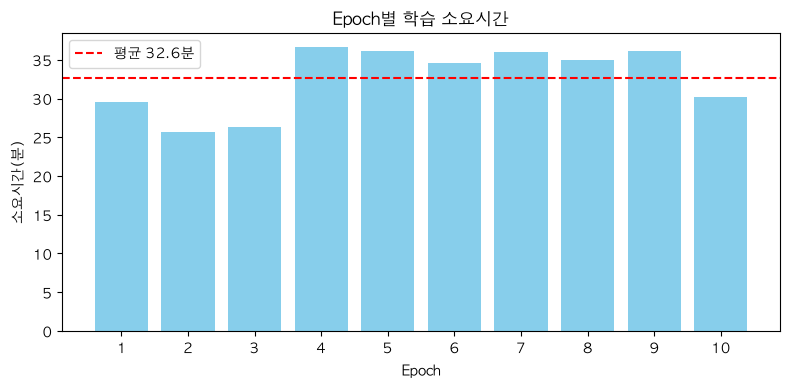

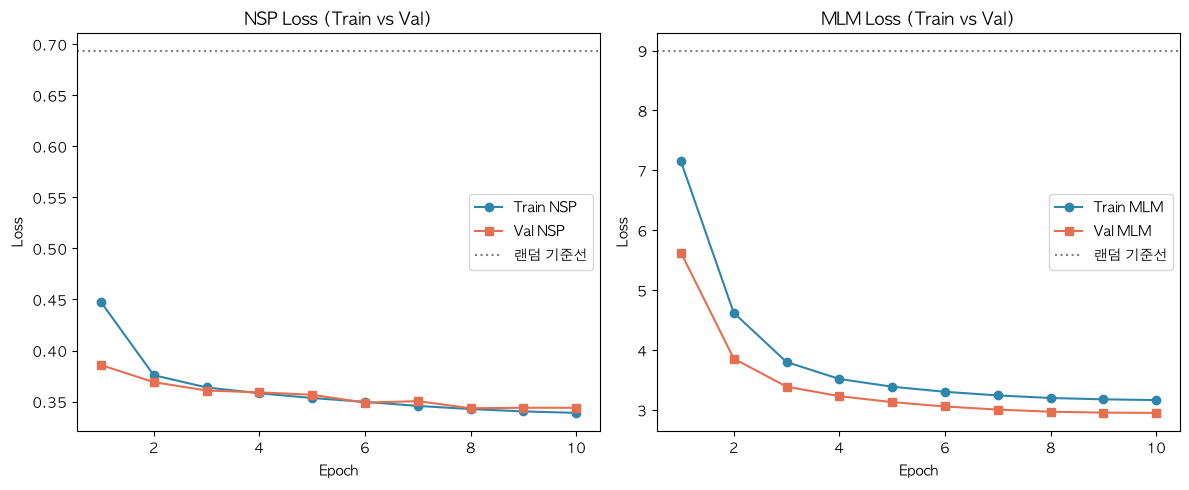

In [114]:
import matplotlib.pyplot as plt
import math

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 소요시간 그래프
epoch_times = [29.5, 25.7, 26.3, 36.6, 36.1, 34.6, 36.0, 35.0, 36.1, 30.2]
total_time = sum(epoch_times)
print(f"총 학습 시간: {total_time:.1f}분 ({total_time/60:.2f}시간)")
print(f"평균 epoch 소요시간: {total_time/len(epoch_times):.1f}분")

plt.figure(figsize=(8, 4))
plt.bar(range(1, len(epoch_times)+1), epoch_times, color='skyblue')
plt.axhline(y=total_time/len(epoch_times), color='red', linestyle='--', label=f'평균 {total_time/len(epoch_times):.1f}분')
plt.xlabel('Epoch')
plt.ylabel('소요시간(분)')
plt.title('Epoch별 학습 소요시간')
plt.xticks(range(1, len(epoch_times)+1))
plt.legend()
plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/bert_epoch_time.png")
plt.show()


# Train/Val Loss 그래프
pochs_range = range(1, len(history['train_nsp_loss']) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_nsp_loss'], color='#2E86AB', marker='o', label='Train NSP')
plt.plot(epochs_range, history['val_nsp_loss'], color='#E76F51', marker='s', label='Val NSP')
plt.axhline(y=math.log(2), color='gray', linestyle=':', label='랜덤 기준선')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('NSP Loss (Train vs Val)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_mlm_loss'], color='#2E86AB', marker='o', label='Train MLM')
plt.plot(epochs_range, history['val_mlm_loss'], color='#E76F51', marker='s', label='Val MLM')
plt.axhline(y=math.log(config.n_vocab), color='gray', linestyle=':', label='랜덤 기준선')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('MLM Loss (Train vs Val)')
plt.legend()

plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/bert_pretrain_loss.png")
plt.show()

##### Accuracy Graph

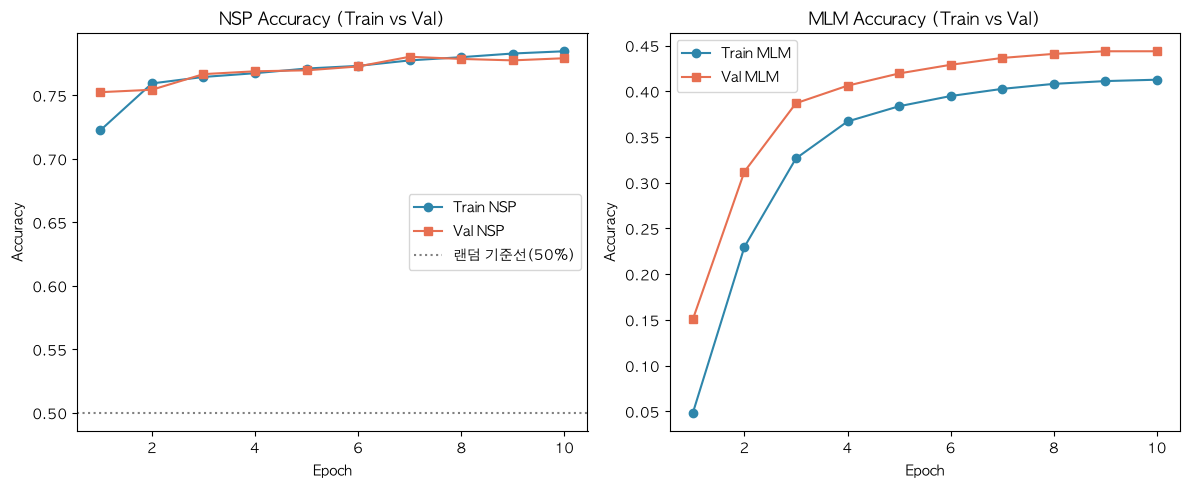

In [115]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_nsp_acc'], color='#2E86AB', marker='o', label='Train NSP')
plt.plot(epochs_range, history['val_nsp_acc'], color='#E76F51', marker='s', label='Val NSP')
plt.axhline(y=0.5, color='gray', linestyle=':', label='랜덤 기준선(50%)')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title('NSP Accuracy (Train vs Val)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_mlm_acc'], color='#2E86AB', marker='o', label='Train MLM')
plt.plot(epochs_range, history['val_mlm_acc'], color='#E76F51', marker='s', label='Val MLM')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title('MLM Accuracy (Train vs Val)')
plt.legend()

plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/bert_pretrain_accuracy.png")
plt.show()

---

#### MLM 빈칸 채우기 Test

In [116]:
import torch.nn.functional as F

@torch.no_grad()
def predict_masked_word(model, text, vocab, device, n_seq, top_k=5):
    """문장 안의 [MASK] 자리에 어떤 단어가 들어갈지 예측 (상위 top_k개)"""
    model.eval()
    tokens = vocab.encode_as_pieces(text)
    tokens = ["[CLS]"] + tokens + ["[SEP]"]

    if "[MASK]" not in tokens:
        raise ValueError("문장에 [MASK]를 하나 넣어주세요. 예: '오늘 날씨가 정말 [MASK] .'")
    mask_pos = tokens.index("[MASK]")

    ids = [vocab.piece_to_id(t) for t in tokens]
    ids = (ids + [PAD_ID] * (n_seq - len(ids)))[:n_seq]
    segment = [0] * n_seq

    enc = torch.tensor([ids], dtype=torch.long, device=device)
    seg = torch.tensor([segment], dtype=torch.long, device=device)

    _, outputs_mlm = model(enc, seg)
    probs = F.softmax(outputs_mlm[0, mask_pos], dim=-1)
    topk = torch.topk(probs, top_k)

    print(f"입력: {text}")
    print(f"[MASK] 위치 예측 (상위 {top_k}개):")
    for score, idx in zip(topk.values, topk.indices):
        print(f"  {vocab.id_to_piece(int(idx)):>10s} : {score.item()*100:.1f}%")
    print()


# --- 실제 테스트 ---
predict_masked_word(pre_train_model, "오늘 날씨가 정말 [MASK] .", vocab, device, n_seq)
predict_masked_word(pre_train_model, "나는 학교에 [MASK] 갔다.", vocab, device, n_seq)
predict_masked_word(pre_train_model, "대한민국의 수도는 [MASK] 이다.", vocab, device, n_seq)

입력: 오늘 날씨가 정말 [MASK] .
[MASK] 위치 예측 (상위 5개):
           . : 42.6%
           딴 : 3.6%
           읍 : 2.7%
           는 : 1.6%
           짝 : 1.6%

입력: 나는 학교에 [MASK] 갔다.
[MASK] 위치 예측 (상위 5개):
           쳐 : 23.0%
         쪽으로 : 4.1%
          까지 : 3.2%
           갔 : 2.7%
           펴 : 2.5%

입력: 대한민국의 수도는 [MASK] 이다.
[MASK] 위치 예측 (상위 5개):
           딴 : 25.3%
           ※ : 5.2%
          했던 : 4.9%
           꼽 : 3.3%
           前 : 3.1%



#### MLM 결과 분석
"오늘 날씨가 정말 [MASK] ."
      ↓
1위 예측: "." (42.6%)
->문장이 마침표 근처에서 끝나는 패턴이라는 표면적 통계만 익힌 결과(의미 이해보다 얕은 패턴 매칭)

딴, 읍, 짝, 쳐, 펴, ※, 前, 꼽 같은 조각들은, 문법적으로 말이 안 되는 경우
->※(주석 기호)나 前(한자)이 튀어나온 건, 나무위키 특유의 표기 각주나 한자 병기를 그대로 흡수한 흔적

#### MLM 결과 원인 분석
1) 도메인 불일치
학습 데이터는 나무위키인데, 테스트 문장은 일상 대화체

2) 토큰 단위 마스킹의 부작용
토큰 단위 마스킹은 "진짜 의미 이해" 대신 "주변 조각으로 커닝하는 지름길 학습"을 유도함.
의미보다 표면적 패턴(마침표 위치 등)에 의존하는 모습이 보인다.

3) 작은 모델 + 짧은 학습
현 모델의 165만 파라미터, 10 epoch는 BERT(1억+ 파라미터, 훨씬 오래 학습)에 비해 작은 규모.

#### 도메인 불일치 학습 데이터 검증해보기

In [117]:
predict_masked_word(pre_train_model, "이 문서는 [MASK] 에 대해 다룬다.", vocab, device, n_seq)
predict_masked_word(pre_train_model, "그는 1990년에 [MASK] 에서 태어났다.", vocab, device, n_seq)

입력: 이 문서는 [MASK] 에 대해 다룬다.
[MASK] 위치 예측 (상위 5개):
           칙 : 12.1%
           쓸 : 5.8%
          에서 : 3.6%
           낱 : 3.3%
           는 : 3.3%

입력: 그는 1990년에 [MASK] 에서 태어났다.
[MASK] 위치 예측 (상위 5개):
         쪽으로 : 5.8%
          에서 : 3.3%
           뮌 : 2.4%
           린 : 2.3%
           앵 : 2.3%



```
MLM 예측 결과(도메인 일치 결과 분석)
입력: 이 문서는 [MASK] 에 대해 다룬다.
    -> 칙 : 12.1%  정답(O)

입력: 그는 1990년에 [MASK] 에서 태어났다.
[MASK] 위치 예측 (상위 5개):
    ->쪽으로 : 5.8% / 에서 : 3.3%는 여전히 표면적 통계만 익힌 결과 보여줌 
    -> 뮌 : 2.4% / 린 : 2.3% 은 뮌은 뮌헨(Munich), 린은 베를린(Berlin)처럼 지명의 일부로 자주 쓰이는 음절
    =>이런 문장 구조에는 지명이 온다는 패턴을 어느 정도 익혔다는 신호로 볼 수 있음
```

---

#### NSP 문장 연결성 판단 테스트

In [118]:
@torch.no_grad()
def predict_nsp(model, sent_a, sent_b, vocab, device, n_seq):
    """두 문장이 실제로 이어지는 문장인지 예측"""
    model.eval()
    tokens_a = vocab.encode_as_pieces(sent_a)
    tokens_b = vocab.encode_as_pieces(sent_b)
    tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
    segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)

    ids = [vocab.piece_to_id(t) for t in tokens]
    if len(ids) > n_seq:
        ids, segment = ids[:n_seq], segment[:n_seq]
    else:
        pad_len = n_seq - len(ids)
        ids += [PAD_ID] * pad_len
        segment += [0] * pad_len

    enc = torch.tensor([ids], dtype=torch.long, device=device)
    seg = torch.tensor([segment], dtype=torch.long, device=device)

    outputs_nsp, _ = model(enc, seg)
    probs = F.softmax(outputs_nsp[0], dim=-1)
    pred = probs.argmax().item()

    print(f"A: {sent_a}")
    print(f"B: {sent_b}")
    print(f"예측: {'이어지는 문장' if pred == 1 else '이어지지 않는 문장'} (확률: {probs[pred].item()*100:.1f}%)")
    print()


# --- 실제 테스트 (자연스러운 쌍 vs 무관한 쌍) ---
predict_nsp(pre_train_model, "오늘 날씨가 정말 좋다.", "그래서 산책을 나가기로 했다.", vocab, device, n_seq)
predict_nsp(pre_train_model, "오늘 날씨가 정말 좋다.", "컴퓨터는 전자 부품으로 이루어져 있다.", vocab, device, n_seq)

A: 오늘 날씨가 정말 좋다.
B: 그래서 산책을 나가기로 했다.
예측: 이어지지 않는 문장 (확률: 58.0%)

A: 오늘 날씨가 정말 좋다.
B: 컴퓨터는 전자 부품으로 이루어져 있다.
예측: 이어지지 않는 문장 (확률: 58.9%)



In [119]:
predict_nsp(pre_train_model, "손흥민은 토트넘 소속 축구선수다.", "그는 2019년 아시안컵에 출전했다.", vocab, device, n_seq)
predict_nsp(pre_train_model, "손흥민은 토트넘 소속 축구선수다.", "김치는 발효 식품이다.", vocab, device, n_seq)

A: 손흥민은 토트넘 소속 축구선수다.
B: 그는 2019년 아시안컵에 출전했다.
예측: 이어지는 문장 (확률: 57.8%)

A: 손흥민은 토트넘 소속 축구선수다.
B: 김치는 발효 식품이다.
예측: 이어지는 문장 (확률: 63.2%)



### NSP 문장 연결성 판단 테스트 분석
임의로 작성한 문장 쌍에 대해 두 경우 모두 유사한 확률(58% 안팎)로 '이어지지 않음'으로 예측했다. 
이는 모델의 실패라기보다, NSP 태스크 정의가 원조 BERT(임의 문서에서 추출한 무관한 문장과의 구분)와 달리
같은 문단 내 두 조각의 순서 판별'로 구성되었기 때문으로 분석된다. 
정확한 NSP 성능 평가를 위해서는 학습데이터로 사용되지 않은 Validation data에서 테스트해야 한다는 결론을 내렸다.

### Validation data로 NSP 테스트

In [8]:
import numpy as np

random_seed = 1234
total = 918185
val_ratio = 0.02

rng = np.random.RandomState(random_seed)
all_indices = rng.permutation(total)
n_val = int(total * val_ratio)
val_indices = all_indices[:n_val]
train_indices = all_indices[n_val:]

print(f"val: {len(val_indices):,}")

val: 18,363


In [9]:
MEMMAP_DIR = "./memmap"
n_seq = 128

enc_tokens = np.memmap(f'{MEMMAP_DIR}/enc_tokens.memmap', mode='r', dtype=np.int32, shape=(total, n_seq))
labels_nsp = np.memmap(f'{MEMMAP_DIR}/labels_nsp.memmap', mode='r', dtype=np.int32, shape=(total,))
lengths    = np.memmap(f'{MEMMAP_DIR}/lengths.memmap',    mode='r', dtype=np.int32, shape=(total,))

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import sentencepiece as spm

# device
device = torch.device("mps" if torch.backends.mps.is_available()
                       else "cuda" if torch.cuda.is_available()
                       else "cpu")
print("device:", device)

# vocab 
MODEL_DIR = "./models"
vocab = spm.SentencePieceProcessor()
vocab.load(f'{MODEL_DIR}/ko_8000.model')

PAD_ID = vocab.pad_id()
CLS_ID = vocab.piece_to_id("[CLS]")
SEP_ID = vocab.piece_to_id("[SEP]")
MASK_ID = vocab.piece_to_id("[MASK]")
print("PAD:", PAD_ID, "/ CLS:", CLS_ID, "/ SEP:", SEP_ID, "/ MASK:", MASK_ID)


#모델 클래스 정의 
class Config(dict):
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__

def get_pad_mask(tokens, i_pad=0):
    mask = (tokens == i_pad).float()
    return mask.unsqueeze(1)

class SharedEmbedding(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.n_vocab, self.d_model = config.n_vocab, config.d_model
        self.shared_weights = nn.Parameter(torch.empty(self.n_vocab, self.d_model))
        nn.init.trunc_normal_(self.shared_weights, std=0.02)
    def forward(self, inputs, mode="embedding"):
        if mode == "embedding":
            return self.shared_weights[inputs.long()]
        n_batch, n_seq_, _ = inputs.shape
        inputs = inputs.view(-1, self.d_model)
        outputs = torch.matmul(inputs, self.shared_weights.T)
        return outputs.view(n_batch, n_seq_, self.n_vocab)

class PositionEmbedding(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.embedding = nn.Embedding(config.n_seq, config.d_model)
        nn.init.trunc_normal_(self.embedding.weight, std=0.02)
    def forward(self, inputs):
        position = torch.cumsum(torch.ones_like(inputs), dim=1) - 1
        return self.embedding(position.long())

class ScaleDotProductAttention(nn.Module):
    def forward(self, Q, K, V, attn_mask):
        attn_score = torch.matmul(Q, K.transpose(-2, -1))
        scale = torch.sqrt(torch.tensor(K.shape[-1], dtype=torch.float32))
        attn_scale = attn_score / scale - (attn_mask * 1e9)
        return torch.matmul(F.softmax(attn_scale, dim=-1), V)

class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.d_model, self.n_head, self.d_head = config.d_model, config.n_head, config.d_head
        self.W_Q = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_K = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_V = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.attention = ScaleDotProductAttention()
        self.W_O = nn.Linear(config.n_head * config.d_head, config.d_model)
    def forward(self, Q, K, V, attn_mask):
        bs = Q.shape[0]
        Q_m = self.W_Q(Q).view(bs, -1, self.n_head, self.d_head).transpose(1, 2)
        K_m = self.W_K(K).view(bs, -1, self.n_head, self.d_head).transpose(1, 2)
        V_m = self.W_V(V).view(bs, -1, self.n_head, self.d_head).transpose(1, 2)
        attn_out = self.attention(Q_m, K_m, V_m, attn_mask.unsqueeze(1))
        attn_out = attn_out.transpose(1, 2).contiguous().view(bs, -1, self.n_head * self.d_head)
        return self.W_O(attn_out)

class PositionWiseFeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.W_1 = nn.Linear(config.d_model, config.d_ff)
        self.W_2 = nn.Linear(config.d_ff, config.d_model)
        self.gelu = nn.GELU()
    def forward(self, inputs):
        return self.W_2(self.gelu(self.W_1(inputs)))

class EncoderLayer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.self_attention = MultiHeadAttention(config)
        self.norm1 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.ffn = PositionWiseFeedForward(config)
        self.norm2 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.dropout = nn.Dropout(config.dropout)
    def forward(self, enc_embed, self_mask):
        v = self.norm1(enc_embed + self.dropout(self.self_attention(enc_embed, enc_embed, enc_embed, self_mask)))
        return self.norm2(v + self.dropout(self.ffn(v)))

class BERT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.i_pad = config.i_pad
        self.embedding = SharedEmbedding(config)
        self.position = PositionEmbedding(config)
        self.segment = nn.Embedding(2, config.d_model)
        self.norm = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.encoder_layers = nn.ModuleList([EncoderLayer(config) for _ in range(config.n_layer)])
        self.dropout = nn.Dropout(config.dropout)
    def forward(self, enc_tokens_, segments_):
        mask = get_pad_mask(enc_tokens_, self.i_pad)
        embed = self.embedding(enc_tokens_) + self.position(enc_tokens_) + self.segment(segments_)
        out = self.dropout(self.norm(embed))
        for layer in self.encoder_layers:
            out = layer(out, mask)
        return out[:, 0], self.embedding(out, mode="linear")

class PooledOutput(nn.Module):
    def __init__(self, config, n_output):
        super().__init__()
        self.dense1 = nn.Linear(config.d_model, config.d_model)
        self.dense2 = nn.Linear(config.d_model, n_output, bias=False)
    def forward(self, inputs):
        return self.dense2(torch.tanh(self.dense1(inputs)))

class PreTrainModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.bert = BERT(config)
        self.pooled_output = PooledOutput(config, 2)
    def forward(self, enc_tokens_, segments_):
        logits_cls, logits_lm = self.bert(enc_tokens_.long(), segments_.long())
        return self.pooled_output(logits_cls), logits_lm

def build_model_pre_train(config):
    return PreTrainModel(config)


# config
config = Config({
    "d_model": 128, "n_head": 4, "d_head": 32, "dropout": 0.1, "d_ff": 512,
    "layernorm_epsilon": 1e-6, "n_layer": 3, "n_seq": n_seq,
    "n_vocab": len(vocab), "i_pad": PAD_ID,
})

pre_train_model = build_model_pre_train(config).to(device)
pre_train_model.load_state_dict(torch.load(f"{MODEL_DIR}/bert_pretrain_best.pt", map_location=device))
pre_train_model.eval()
print("모델 복구 완료")


# predict_nsp 함수
@torch.no_grad()
def predict_nsp(model, sent_a, sent_b, vocab, device, n_seq):
    model.eval()
    tokens_a = vocab.encode_as_pieces(sent_a)
    tokens_b = vocab.encode_as_pieces(sent_b)
    tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
    segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
    ids = [vocab.piece_to_id(t) for t in tokens]
    if len(ids) > n_seq:
        ids, segment = ids[:n_seq], segment[:n_seq]
    else:
        pad_len = n_seq - len(ids)
        ids += [PAD_ID] * pad_len
        segment += [0] * pad_len
    enc = torch.tensor([ids], dtype=torch.long, device=device)
    seg = torch.tensor([segment], dtype=torch.long, device=device)
    outputs_nsp, _ = model(enc, seg)
    probs = F.softmax(outputs_nsp[0], dim=-1)
    pred = probs.argmax().item()
    print(f"A: {sent_a}")
    print(f"B: {sent_b}")
    print(f"예측: {'이어지는 문장' if pred == 1 else '이어지지 않는 문장'} (확률: {probs[pred].item()*100:.1f}%)")

print("predict_nsp 함수 준비 완료")

device: mps
PAD: 0 / CLS: 5 / SEP: 4 / MASK: 6
모델 복구 완료
predict_nsp 함수 준비 완료


In [14]:
sample_val_idx = int(np.random.choice(val_indices))
length = int(lengths[sample_val_idx])
token_ids = enc_tokens[sample_val_idx][:length]
true_label = int(labels_nsp[sample_val_idx])
sep_positions = [i for i, t in enumerate(token_ids) if t == SEP_ID]
a_ids = token_ids[1:sep_positions[0]]
b_ids = token_ids[sep_positions[0]+1 : sep_positions[1]]
sent_a = vocab.decode_ids(a_ids.tolist())
sent_b = vocab.decode_ids(b_ids.tolist())
print(f"검증셋 idx={sample_val_idx}")
print(f"실제 정답 is_next: {true_label}")
predict_nsp(pre_train_model, sent_a, sent_b, vocab, device, n_seq)
print()

검증셋 idx=255906
실제 정답 is_next: 1
A: 정주 표절사
B: 정주 표절사(定州 表節祠)는 평안북도 정주시에 있는 사우이다. 조선 순조 때 홍경래의 난으로 죽은 충렬공 정시(忠烈公 鄭 ⁇ )를 비롯한 7의사를 모시기 위해 지어졌고, 1824년 사액을 받았다. 정시는 난이 발발한 직후 군민을 모아 적에 대항하려다 사로잡히자 투항을 거부하여 살해당하였다. 나머지 6인의 의사는 한호운(韓浩運)·백경한(
예측: 이어지는 문장 (확률: 100.0%)



In [15]:
sample_val_idx = int(np.random.choice(val_indices))
length = int(lengths[sample_val_idx])
token_ids = enc_tokens[sample_val_idx][:length]
true_label = int(labels_nsp[sample_val_idx])
sep_positions = [i for i, t in enumerate(token_ids) if t == SEP_ID]
a_ids = token_ids[1:sep_positions[0]]
b_ids = token_ids[sep_positions[0]+1 : sep_positions[1]]
sent_a = vocab.decode_ids(a_ids.tolist())
sent_b = vocab.decode_ids(b_ids.tolist())
print(f"검증셋 idx={sample_val_idx}")
print(f"실제 정답 is_next: {true_label}")
predict_nsp(pre_train_model, sent_a, sent_b, vocab, device, n_seq)
print()

검증셋 idx=476476
실제 정답 is_next: 1
A: 브릿 로버트슨
B: 브릿 로버트슨(, 1990년 4월 18일 ~ )은 미국의 배우이다. 스티븐 킹의 동명 소설을 원작으로 한 언더 더 돔 (드라마)시즌1과 시즌2 1회까지 출연하였다. 언더 더 돔 (드라마)은 에서 시즌3 13회까지 방영되었다
예측: 이어지는 문장 (확률: 100.0%)



In [16]:
sample_val_idx = int(np.random.choice(val_indices))
length = int(lengths[sample_val_idx])
token_ids = enc_tokens[sample_val_idx][:length]
true_label = int(labels_nsp[sample_val_idx])
sep_positions = [i for i, t in enumerate(token_ids) if t == SEP_ID]
a_ids = token_ids[1:sep_positions[0]]
b_ids = token_ids[sep_positions[0]+1 : sep_positions[1]]
sent_a = vocab.decode_ids(a_ids.tolist())
sent_b = vocab.decode_ids(b_ids.tolist())
print(f"검증셋 idx={sample_val_idx}")
print(f"실제 정답 is_next: {true_label}")
predict_nsp(pre_train_model, sent_a, sent_b, vocab, device, n_seq)
print()

검증셋 idx=169151
실제 정답 is_next: 1
A: 중화민국 내정부 경정서
B: 내정부경정서(內政部警政署, National Police Agency)는 경찰청에 해당하는 중화민국 내정부 소속 행정 부서로 1946년에 설립되었다. 대만, 펑후, 진먼하고 마쭈에서의 경찰 업무를 담당하는 최고 기관이고, 주로 치안 문제를 담당한다. 현재 총 본부는 타이베이에 있다.
예측: 이어지는 문장 (확률: 100.0%)



In [17]:
sample_val_idx = int(np.random.choice(val_indices))
length = int(lengths[sample_val_idx])
token_ids = enc_tokens[sample_val_idx][:length]
true_label = int(labels_nsp[sample_val_idx])
sep_positions = [i for i, t in enumerate(token_ids) if t == SEP_ID]
a_ids = token_ids[1:sep_positions[0]]
b_ids = token_ids[sep_positions[0]+1 : sep_positions[1]]
sent_a = vocab.decode_ids(a_ids.tolist())
sent_b = vocab.decode_ids(b_ids.tolist())
print(f"검증셋 idx={sample_val_idx}")
print(f"실제 정답 is_next: {true_label}")
predict_nsp(pre_train_model, sent_a, sent_b, vocab, device, n_seq)
print()

검증셋 idx=510291
실제 정답 is_next: 1
A: 애셔 로스 애셔 폴 로스(Asher Paul Roth, 1985년 8월 11일 ~ )는 미국의 래퍼이다.
B: 1985년 필라델피아 주 근교의 모리스빌에서 태어나 성장한다. 고등학생이 되면서 친구와 함께 랩을 하게되었으며, 본격적으로 작사와 녹음 활동을 수행하게된다. 레코딩한 CD는 고등학교에서 팔았고, 전문 래퍼가 될 것을 결심하였다. 대학에 진학한 후에도 마이스페이스에서 자신의 랩을 꾸준히 업로드를 하여 지명도를 올리기
예측: 이어지는 문장 (확률: 100.0%)



In [18]:
sample_val_idx = int(np.random.choice(val_indices))
length = int(lengths[sample_val_idx])
token_ids = enc_tokens[sample_val_idx][:length]
true_label = int(labels_nsp[sample_val_idx])
sep_positions = [i for i, t in enumerate(token_ids) if t == SEP_ID]
a_ids = token_ids[1:sep_positions[0]]
b_ids = token_ids[sep_positions[0]+1 : sep_positions[1]]
sent_a = vocab.decode_ids(a_ids.tolist())
sent_b = vocab.decode_ids(b_ids.tolist())
print(f"검증셋 idx={sample_val_idx}")
print(f"실제 정답 is_next: {true_label}")
predict_nsp(pre_train_model, sent_a, sent_b, vocab, device, n_seq)
print()

검증셋 idx=897559
실제 정답 is_next: 0
A: 수지레스피아(水枝레스피아, )는 대한민국 경기도 용인시에 있는 하수 처리 시설이다. 주요 시설이 지하에 설치되어 있으며, 지상은 아르피아체육공원이 조성되어 있다.
B: 수지레스피아
예측: 이어지지 않는 문장 (확률: 100.0%)



#### 결과 분석
##### 모델이 순서가 맞는지를 판단하는 능력을 확실히 학습했다는 증거 보임.
##### ->학습에 전혀 사용되지 않은 검증 데이터(val_indices)로 테스트한 결과, NSP 순서 판별 안에서는 모델이 정확히 작동함이 확인됨. 

####

## 프로젝트 결과

### 수렴 여부
Train/Val 모두 초반(Epoch 1→2)에 급격히 개선된 뒤, 점점 완만해지며 수렴하는 전형적인 패턴을 보였다.

| 지표 | Epoch 1 | Epoch 10 | 랜덤 기준선 |
|---|---|---|---|
| Val NSP Loss | 0.386 | 0.344 | 0.693 |
| Val MLM Loss | 5.627 | 2.952 | 8.988 |
| MLM Perplexity | ~278 | ~19.2 | 8,007 |

Epoch 9→10 구간의 val_total(NSP+MLM) 개선폭은 -0.004로, Epoch 1→2의 -1.79에
비해 거의 0에 수렴했다. 10개 epoch 전체에서 매번 val_loss가 갱신되며 최고
기록을 경신했고, train/val 곡선이 끝까지 벌어지지 않아
**과적합 없이 안정적으로 수렴**했다고 판단할 수 있다. 다만 완전히 평평해지지는
않아, 더 많은 epoch를 학습하면 추가 개선 여지가 있어 보인다.

### 모델 크기·학습 시간 관계에 대한 고찰
본 모델은 3층, d_model=128, 파라미터 165만 개의 매우 작은 모델임에도,
10 epoch 학습에 총 5.44시간(평균 32.6분/epoch)이 소요되었다. 이는 모델
크기 대비 예상보다 긴 시간으로, 다음 실험을 통해 원인을 추적했다:

1. Dynamic Masking을 CPU 반복문(어절 단위)에서 GPU 벡터 연산(토큰 단위)으로
   전환했으나 배치당 처리 속도(약 0.156초)에 변화가 없었다.
2. 학습 중 Activity Monitor 확인 결과 CPU·GPU 사용률이 모두 30% 안팎에
   머물러, 특정 리소스가 포화 상태가 아니었다.

이는 PyTorch의 MPS(Apple GPU) 백엔드가 연산 하나하나를 실행할 때
발생하는 고정 오버헤드(dispatch overhead)가, 텐서 크기가 작은 mini BERT의
연산 시간보다 오히려 크게 작용했을 가능성을 나타낸다. 즉 **모델이 작다**는 게
반드시 **학습이 빠르다**로 이어지지 않으며, 특정 하드웨어·프레임워크
조합에서는 모델 크기보다 연산 오버헤드가 학습 시간을 지배할 수 있다는
것을 확인했다.

어절 단위 대신 토큰 단위 마스킹으로 전환한 것은 시간 제약에 따른
절충이었다. 이 부분이 아쉬움이 많이 남는다.


---

### 번외: Static masking vs Dynamic Masking

In [122]:
import copy

# 소규모 subset 준비

exp_train_size = 20000
exp_val_size = 2000

rng2 = np.random.RandomState(42)
exp_train_idx = rng2.choice(train_indices, size=exp_train_size, replace=False)
exp_val_idx = rng2.choice(val_indices, size=exp_val_size, replace=False)

exp_train_dataset = torch.utils.data.Subset(raw_full_dataset, exp_train_idx)
exp_val_dataset = torch.utils.data.Subset(raw_full_dataset, exp_val_idx)

EXP_BATCH_SIZE = 64
EXP_EPOCHS = 5

exp_val_loader = DataLoader(exp_val_dataset, batch_size=EXP_BATCH_SIZE, shuffle=False)

print(f"실험용 train: {exp_train_size} / val: {exp_val_size}")


# 같은 초기 가중치

_init_model = build_model_pre_train(config).to(device)
init_state = copy.deepcopy(_init_model.state_dict())


# Static masking 한 번 고정으로 데이터셋으로 만듦
@torch.no_grad()
def build_static_masked_dataset(raw_dataset, batch_size, device):
    loader = DataLoader(raw_dataset, batch_size=batch_size, shuffle=False)
    all_enc, all_seg, all_nsp, all_mlm = [], [], [], []
    for enc_raw, seg_batch, nsp_batch in loader:
        enc_raw, seg_batch, nsp_batch = enc_raw.to(device), seg_batch.to(device), nsp_batch.to(device)
        enc_batch, mlm_batch = mask_batch_gpu(enc_raw, CLS_ID, SEP_ID, PAD_ID, MASK_ID, config.n_vocab)
        all_enc.append(enc_batch.cpu()); all_seg.append(seg_batch.cpu())
        all_nsp.append(nsp_batch.cpu()); all_mlm.append(mlm_batch.cpu())
    return torch.utils.data.TensorDataset(torch.cat(all_enc), torch.cat(all_seg), torch.cat(all_nsp), torch.cat(all_mlm))

static_dataset = build_static_masked_dataset(exp_train_dataset, EXP_BATCH_SIZE, device)
static_train_loader = DataLoader(static_dataset, batch_size=EXP_BATCH_SIZE, shuffle=True)
# shuffle=True는 순서 섞음

dynamic_train_loader = DataLoader(exp_train_dataset, batch_size=EXP_BATCH_SIZE, shuffle=True)
# 원본 그대로, 매번 __iter__될 때마다 다시 마스킹됨



# 공통 학습 함수 (variant만 다르게)

def run_variant(name, train_loader, is_dynamic, init_state, val_loader, epochs):
    model = build_model_pre_train(config).to(device)
    model.load_state_dict(init_state)   # 완전히 같은 출발점
    optimizer = optim.Adam(model.parameters(), lr=2.5e-4)   # 짧은 실험이라 스케줄러 없이 고정 lr

    history = {"train_loss": [], "val_loss": []}
    for epoch in range(epochs):
        model.train()
        total_loss, n_batches = 0.0, 0
        for batch in train_loader:
            if is_dynamic:
                enc_raw, seg_batch, nsp_batch = batch
                enc_raw, seg_batch, nsp_batch = enc_raw.to(device), seg_batch.to(device), nsp_batch.to(device)
                enc_batch, mlm_batch = mask_batch_gpu(enc_raw, CLS_ID, SEP_ID, PAD_ID, MASK_ID, config.n_vocab)
                # 매 배치마다 새로 마스킹 (Dynamic)
            else:
                enc_batch, seg_batch, nsp_batch, mlm_batch = batch
                enc_batch, seg_batch = enc_batch.to(device), seg_batch.to(device)
                nsp_batch, mlm_batch = nsp_batch.to(device), mlm_batch.to(device)
                # 미리 마스킹해둔 거 씀 (Static)

            optimizer.zero_grad()
            outputs_nsp, outputs_mlm = model(enc_batch, seg_batch)
            loss = (loss_fn_nsp(outputs_nsp, nsp_batch)
                    + loss_fn_mlm(outputs_mlm.view(-1, config.n_vocab), mlm_batch.view(-1)))
            loss.backward()
            optimizer.step()
            total_loss += loss.item(); n_batches += 1

        train_loss = total_loss / n_batches
        val_result = evaluate_bert_gpu(model, val_loader, loss_fn_nsp, loss_fn_mlm, device)
        val_loss = val_result['nsp_loss'] + val_result['mlm_loss']

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        print(f"[{name}] Epoch {epoch+1}/{epochs} - train:{train_loss:.4f} val:{val_loss:.4f}")

    return history



# 실행 및 비교

print("=== Static Masking ===")
static_history = run_variant("Static", static_train_loader, False, init_state, exp_val_loader, EXP_EPOCHS)

print("\n=== Dynamic Masking ===")
dynamic_history = run_variant("Dynamic", dynamic_train_loader, True, init_state, exp_val_loader, EXP_EPOCHS)

실험용 train: 20000 / val: 2000
=== Static Masking ===
[Static] Epoch 1/5 - train:8.1796 val:7.9408
[Static] Epoch 2/5 - train:7.9324 val:7.9063
[Static] Epoch 3/5 - train:7.8779 val:7.8598
[Static] Epoch 4/5 - train:7.8557 val:7.8758
[Static] Epoch 5/5 - train:7.8352 val:7.8568

=== Dynamic Masking ===
[Dynamic] Epoch 1/5 - train:8.1868 val:7.9410
[Dynamic] Epoch 2/5 - train:7.9279 val:7.9135
[Dynamic] Epoch 3/5 - train:7.8931 val:7.8647
[Dynamic] Epoch 4/5 - train:7.8682 val:7.8434
[Dynamic] Epoch 5/5 - train:7.8497 val:7.8231


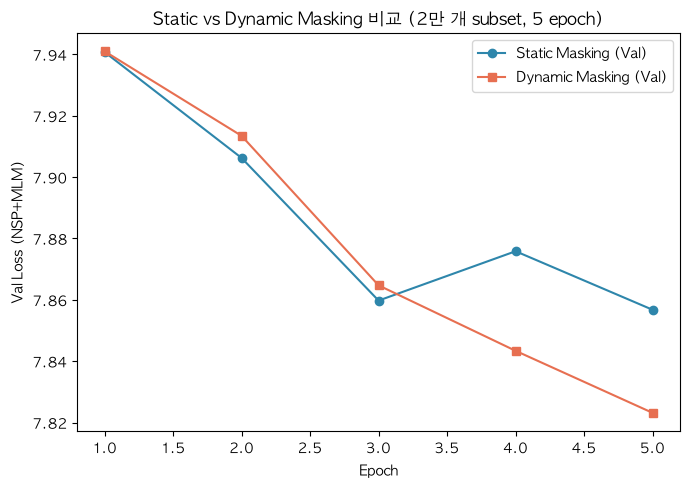

In [123]:
plt.figure(figsize=(7, 5))
ep_range = range(1, EXP_EPOCHS + 1)
plt.plot(ep_range, static_history["val_loss"], color='#2E86AB', marker='o', label='Static Masking (Val)')
plt.plot(ep_range, dynamic_history["val_loss"], color='#E76F51', marker='s', label='Dynamic Masking (Val)')
plt.xlabel('Epoch'); plt.ylabel('Val Loss (NSP+MLM)')
plt.title('Static vs Dynamic Masking 비교 (2만 개 subset, 5 epoch)')
plt.legend()
plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/static_vs_dynamic_comparison.png")
plt.show()

### Static masking vs Dynamic masking (2만 개, 5 Epoch)

```
초반 1~3 epoch에서는 Static과 Dynamic Masking 간 유의미한 차이가 없었지만 Epoch 4부터 갈라졌다. 
Static Masking은 Epoch 3(val loss 7.8598)에서 최저점을 찍은 뒤 Epoch 4에 오히려 상승(7.8758)했고, 
5 epoch 종료 시점까지도 Epoch 3 수준을 회복하는 데 그쳤다. 
반면 Dynamic Masking은 5 epoch 내내 감소하며 최종적으로 Static 대비 val loss가 0.034 더 낮았다. 
->Static Masking이 소수의 epoch만으로도 고정된 마스킹 패턴에 대한 과적합 조짐을 보이는 반면, 
Dynamic Masking은 매 epoch 새로운 마스킹 패턴을 제공함으로써 지속적인 학습 신호를 유지함을 볼 수 있다.
```